<div style="
  width:100%;
  border-radius:20px;
  padding:28px 30px;
  text-align:center;
  background:linear-gradient(135deg,#f8fbff 0%, #eef4ff 42%, #fff8f1 72%, #faf5ff 100%);
  border:1px solid rgba(99,102,241,0.15);
  font-family:-apple-system,BlinkMacSystemFont,'Segoe UI',Inter,Arial,sans-serif;
">
  <div style="
    display:inline-block;
    padding:6px 14px;
    border-radius:999px;
    border:1px solid rgba(59,130,246,0.18);
    background:rgba(255,255,255,0.92);
    font-size:12px;
    font-weight:700;
    color:#475569;
    margin-bottom:14px;
  ">
    Decision-Support Analytics • Workforce Risk Intelligence
  </div>

  <div style="
    font-size:32px;
    font-weight:900;
    line-height:1.18;
    margin-bottom:10px;
  ">
    <span style="color:#2563EB;">HR</span>
    <span style="color:#94A3B8;"> — </span>
    <span style="color:#0F172A;">Attrition</span>
    <span style="color:#94A3B8;"> &times; </span>
    <span style="color:#EA580C;">Retention</span>
    <span style="color:#94A3B8;"> &times; </span>
    <span style="color:#7C3AED;">Intelligence</span>
  </div>

  <div style="
    font-size:15px;
    font-weight:600;
    color:#64748B;
  ">
    Workforce Stability • Experience Signals • Career Friction • Interpretable Risk Patterns
  </div>
</div>


![](https://raw.githubusercontent.com/rbyzk/MachineLearningProjects/4cd2b09a7c088d11e1ad73b7f70e25c1989fa64d/HR_Analysis/HR.png)

## Project Overview

Employee attrition is one of the most important workforce signals because it can reflect pressure points in how people experience work, growth, compensation, and day-to-day stability across the organization.

This notebook takes a broad and practical approach to understanding attrition. It begins by reading the workforce structure, then moves into signal discovery, segmentation, feature engineering, modelling, explainability, and a visible monitoring layer. The goal is to understand what the data says clearly, where risk appears to concentrate, and which patterns are strong enough to support future HR analytics work.

This project is designed to answer a practical set of HR questions:

- Where does attrition concentrate across departments and job roles?
- How do overtime, compensation, tenure, and employee experience relate to attrition?
- Which employee segments appear most exposed?
- Which patterns are consistent enough to support clearer retention decisions?
- How can these findings be extended into a visible monitoring view?

The notebook follows a decision-support structure:

**business framing → data understanding → executive KPIs → diagnostic EDA → segmentation → feature engineering → modelling → explainability → monitoring**

<div style="background:linear-gradient(90deg,#eff6ff 0%,#fff7ed 52%,#faf5ff 100%); padding:18px 22px; border-radius:16px; margin-bottom:14px; border:1px solid rgba(148,163,184,.18);">
  <div style="font-size:18px; font-weight:900; letter-spacing:.03em; text-transform:uppercase; color:#1d4ed8;">
    TL;DR – HR INSIGHTS AT A GLANCE
  </div>
  <div style="font-size:13.5px; margin-top:6px; color:#334155; line-height:1.6;">
    This notebook studies attrition through a full decision-support workflow. It moves from workforce understanding and data readiness into executive KPIs, diagnostic EDA, segment scorecards, engineered signals, interpretable modelling, explainability, and a monitoring view that makes future analytics directions visible.
  </div>
</div>

<table style="width:100%; border-collapse:separate; border-spacing:14px;">
  <tr>
    <td style="width:33.33%; vertical-align:top; background:#eff6ff; border:1px solid #dbeafe; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#1d4ed8; margin-bottom:8px;">📊 Scope of the Analysis</div>
      <div style="font-size:13px; color:#334155; line-height:1.7;">
        • Workforce structure, schema understanding, and attrition baseline<br>
        • Executive KPI reading, diagnostic EDA, and segment-level risk concentration<br>
        • Feature engineering, classification modelling, and explanation of the main drivers<br>
        • Monitoring-ready tables and a final enriched dataset export for downstream use
      </div>
    </td>

   <td style="width:33.33%; vertical-align:top; background:#fff7ed; border:1px solid #fed7aa; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#ea580c; margin-bottom:8px;">💡 Main Reading</div>
      <div style="font-size:13px; color:#7c2d12; line-height:1.7;">
        • Attrition is read across workload, compensation, progression, and employee experience<br>
        • Segment views are used to show where exits gather rather than relying on the headline rate alone<br>
        • The modelling stage is used as a validation layer, not as the only source of interpretation<br>
        • The final monitoring view keeps future analytics ideas visible and concrete
      </div>
    </td>

   <td style="width:33.33%; vertical-align:top; background:#faf5ff; border:1px solid #e9d5ff; border-radius:14px; padding:14px 16px;">
      <div style="font-weight:900; color:#7c3aed; margin-bottom:8px;">🔍 Where to Look</div>
      <div style="font-size:13px; color:#4c1d95; line-height:1.7;">
        • <a href="#4-executive-kpis--workforce-snapshot" style="color:#6366f1; text-decoration:none;">Executive KPIs</a> for the quick workforce read<br>
        • <a href="#5-diagnostic-eda--attrition-signals" style="color:#6366f1; text-decoration:none;">Diagnostic EDA</a> for the core attrition signals<br>
        • <a href="#6-workforce-segmentation--executive-scorecards" style="color:#6366f1; text-decoration:none;">Segmentation</a> for scorecards and risk clusters<br>
        • <a href="#10-monitoring--future-iterations" style="color:#6366f1; text-decoration:none;">Monitoring</a> for visible next-step analytics views
      </div>
    </td>
  </tr>
</table>

<div style="background:#ffffff; border-radius:12px; padding:14px 18px; border:1px solid #e5e7eb; margin-top:10px;">
  <b>📚 Notebook Roadmap</b><br>
  <ul style="margin-top:8px;">
    <li>
      <a href="#0-setup--imports">0. 🧰 Setup & Imports</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Theme configuration, helper functions, resilient data loading, and notebook display utilities
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#1-business-context--decision-questions">1. 🎯 Business Context And Decision Questions</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Business framing, management questions, and the decision perspective guiding the analysis
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#2-dataset-intake--raw">2. 📊 Dataset Intake (Raw)</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Initial review of dataset size, schema structure, and raw records
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#3-data-quality-gate--hr-analytics-readiness">3. 🧹 Data Quality Gate — HR Analytics Readiness</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Checks for missing values, duplicates, low-information fields, and overall analytic readiness
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#4-executive-kpis--workforce-snapshot">4. 📈 Executive KPIs — Workforce Snapshot</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Core workforce metrics that establish the initial attrition and risk picture
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#5-diagnostic-eda--attrition-signals">5. 🔍 Diagnostic EDA — Attrition Signals</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Targeted visual analysis of organizational, workload, reward, and progression patterns
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#6-workforce-segmentation--executive-scorecards">6. 🧾 Workforce Segmentation & Executive Scorecards</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Segment-based scorecards across department, role, and career stage
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#7-feature-engineering--people-risk-signals">7. 🏗️ Feature Engineering — People Risk Signals</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Derived bands, flags, and composite indicators to strengthen risk interpretation
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#8-modelling--attrition-risk-classification">8. 🤖 Modelling — Attrition Risk Classification</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Model benchmarking, champion selection, and practical performance evaluation
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#9-explainability--what-drives-employee-exit">9. 🔎 Explainability — What Drives Employee Exit?</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Interpretation of model drivers and identification of the most influential risk signals
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#10-monitoring-layer--visible-risk-views">10. 👀 Monitoring Layer — Visible Risk Views</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Watchlists, fairness checks, tenure monitoring, and intervention-oriented views
      </span>
    </li>
    <li style="margin-top:6px;">
      <a href="#11-executive-conclusions--data-export">11. 🚀 Executive Conclusions & Data Export</a><br>
      <span style="font-size:13px; color:#4b5563; display:block; margin-left:4px; margin-top:2px;">
        Consolidated conclusions, analytical boundaries, and export of the enriched outputs
      </span>
    </li>
  </ul>
</div>

<a id="0-setup--imports"></a>

# 0. 🧰 Setup & Imports

This section centralizes notebook configuration, the visual theme, display helpers, analytic utilities, and robust data loading paths so the rest of the notebook can stay modular and readable.

In [1]:
import os
import glob
import io
import uuid
import base64
import textwrap
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import HTML, display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import PercentFormatter
from sklearn.base import BaseEstimator, ClassifierMixin, clone

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    average_precision_score,
    recall_score,
    precision_score,
    f1_score,
    fbeta_score,
    balanced_accuracy_score,
    accuracy_score,
    brier_score_loss,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    precision_recall_curve, 
    average_precision_score,
    PrecisionRecallDisplay
)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

In [2]:
THEME = {
    "bg": "#FFFFFF",
    "panel": "#E8EEF8",
    "grid": "#CBD5E1",
    "text": "#0F172A",
    "muted": "#64748B",
    "slate": "#475569",
    "blue": "#2563EB",
    "blue_soft": "#D6E4FF",
    "orange": "#EA580C",
    "orange_soft": "#FFD8BF",
    "purple": "#7C3AED",
    "purple_soft": "#E4D7FF",
    "teal": "#0F9D8A",
    "teal_soft": "#CFEFEA",
    "success_soft": "#DDF6EC",
}

CHART_FIGSIZE = (8.8, 5.4)
CHART_CARD_WIDTH = "86%"

plt.rcParams["figure.figsize"] = CHART_FIGSIZE
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["font.family"] = "DejaVu Sans"

sns.set_theme(style="whitegrid")

BlueOrangePurple = LinearSegmentedColormap.from_list(
    "BlueOrangePurple",
    ["#D6E4FF", "#E4D7FF", "#FFD8BF"],
    N=256
)

DivergingSoft = LinearSegmentedColormap.from_list(
    "DivergingSoft",
    ["#D6E4FF", "#FFFFFF", "#FFD8BF"],
    N=256
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 220)
pd.set_option("styler.render.max_columns", 200)
pd.set_option("styler.render.max_rows", 100)


def remove_spines(ax):
    for s in ["top", "right"]:
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color(THEME["grid"])
    ax.spines["bottom"].set_color(THEME["grid"])


def faint_dashed_ygrid(ax, alpha=0.32, lw=0.85):
    ax.grid(True, axis="y", linestyle="--", linewidth=lw, alpha=alpha, color=THEME["grid"])
    ax.grid(False, axis="x")


def faint_dashed_xgrid(ax, alpha=0.24, lw=0.85):
    ax.grid(True, axis="x", linestyle="--", linewidth=lw, alpha=alpha, color=THEME["grid"])
    ax.grid(False, axis="y")


def style_axis(ax, xlabel=None, ylabel=None, y_percent=False, x_percent=False, xgrid=False):
    if xlabel is not None:
        ax.set_xlabel(xlabel, color=THEME["slate"], labelpad=9)
    if ylabel is not None:
        ax.set_ylabel(ylabel, color=THEME["slate"], labelpad=9)
    ax.tick_params(colors=THEME["slate"])
    remove_spines(ax)
    faint_dashed_xgrid(ax) if xgrid else faint_dashed_ygrid(ax)
    if y_percent:
        ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    if x_percent:
        ax.xaxis.set_major_formatter(PercentFormatter(1.0))


def wrap_ticklabels(ax, axis="x", width=14):
    labels = [
        textwrap.fill(str(t.get_text()), width=width)
        for t in (ax.get_xticklabels() if axis == "x" else ax.get_yticklabels())
    ]
    if axis == "x":
        ax.set_xticklabels(labels)
    else:
        ax.set_yticklabels(labels)


def annotate_bars(ax, fmt="{:.1%}", fontsize=10):
    bars = [p for p in ax.patches if hasattr(p, "get_height") and pd.notna(p.get_height())]
    if not bars:
        return
    max_h = max([p.get_height() for p in bars] + [0])
    offset = max(max_h * 0.03, 0.008)
    for p in bars:
        h = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + offset,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=fontsize,
            color=THEME["text"],
        )


def fig_card(fig, width="84%"):
    fig.patch.set_facecolor("white")
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=170, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    img_b64 = base64.b64encode(buf.getvalue()).decode("utf-8")

    display(HTML(f"""
    <div style="display:flex;justify-content:center;margin:8px 0 18px 0;">
      <img src="data:image/png;base64,{img_b64}" style="display:block;width:{width};max-width:{width};">
    </div>
    """))

def _soft_bg_from_accent(accent):
    return {
        THEME["blue"]: "#EEF4FF",
        THEME["orange"]: "#FFF1E8",
        THEME["purple"]: "#F3EEFF",
        THEME["slate"]: "#F8FAFC",
        THEME["teal"]: "#ECFBF8",
    }.get(accent, "#FFFFFF")


def kpi_cards(cards, width="90%"):
    html = f'<div style="display:flex;justify-content:center;margin:10px 0 12px 0;"><div style="width:{width};display:flex;gap:10px;flex-wrap:wrap;">'
    for c in cards:
        bg = c.get("bg", _soft_bg_from_accent(c.get("accent", THEME["blue"])))
        html += f"""
        <div style="flex:1 1 190px; min-width:190px; border:1px solid rgba(17,24,39,.10);
                    border-radius:14px; padding:12px 14px; background:{bg}; text-align:center;">
          <div style="font-size:12px; font-weight:900; color:{THEME['muted']}; margin-bottom:8px; letter-spacing:.02em;">{c['title']}</div>
          <div style="font-size:22px; font-weight:1000; color:{c.get('accent', THEME['text'])};">{c['value']}</div>
          {f"<div style='font-size:11px;color:{THEME['muted']};margin-top:6px;line-height:1.45;'>{c['note']}</div>" if c.get('note') else ""}
        </div>
        """
    html += "</div></div>"
    display(HTML(html))


def infer_formatters(dfx, precision=2):
    formatters = {}
    percent_tokens = ("rate", "share", "prob", "auc", "recall", "precision", "f1", "accuracy", "lift", "flagrate")
    signed_tokens = ("coefficient", "importance")
    count_tokens = ("rows", "columns", "count", "employees", "headcount", "duplicates", "total", "signals")

    for col in dfx.columns:
        s = dfx[col]
        name = str(col).strip().lower()
        if not pd.api.types.is_numeric_dtype(s):
            continue

        non_null = s.dropna()
        if non_null.empty:
            formatters[col] = "—"
            continue

        if any(tok in name for tok in percent_tokens) and non_null.abs().max() <= 1.5:
            formatters[col] = "{:.1%}"
        elif any(tok in name for tok in signed_tokens) and non_null.abs().max() <= 10:
            formatters[col] = "{:+.3f}"
        elif pd.api.types.is_integer_dtype(s):
            formatters[col] = "{:,.0f}"
        elif any(tok in name for tok in count_tokens) and np.allclose(non_null, np.round(non_null)):
            formatters[col] = "{:,.0f}"
        elif non_null.abs().median() >= 1000:
            formatters[col] = "{:,.0f}"
        else:
            formatters[col] = f"{{:,.{precision}f}}"
    return formatters


def style_table(sty):
    return sty.set_table_styles([
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse"),
                ("width", "max-content"),
                ("min-width", "100%"),
                ("font-size", "12px"),
                ("table-layout", "auto")
            ]
        },
        {
            "selector": "th.col_heading",
            "props": [
                ("background-color", THEME["panel"]),
                ("color", THEME["text"]),
                ("font-weight", "900"),
                ("text-align", "left"),
                ("white-space", "nowrap"),
                ("border", "1px solid rgba(17,24,39,.10)"),
                ("padding", "9px 11px"),
                ("vertical-align", "middle")
            ]
        },
        {
            "selector": "th.row_heading",
            "props": [
                ("background-color", "#FFFFFF"),
                ("color", THEME["muted"]),
                ("font-weight", "700"),
                ("text-align", "left"),
                ("white-space", "nowrap"),
                ("border", "1px solid rgba(17,24,39,.07)"),
                ("padding", "8px 10px"),
                ("vertical-align", "middle")
            ]
        },
        {
            "selector": "td",
            "props": [
                ("border", "1px solid rgba(17,24,39,.07)"),
                ("color", THEME["text"]),
                ("text-align", "left"),
                ("white-space", "nowrap"),
                ("padding", "8px 11px"),
                ("vertical-align", "middle")
            ]
        },
        {
            "selector": "caption",
            "props": [
                ("caption-side", "top"),
                ("font-weight", "900"),
                ("color", THEME["text"]),
                ("padding", "6px 0 10px 0"),
                ("text-align", "left")
            ]
        },
    ]).set_properties(**{
        "background-color": THEME["bg"],
        "white-space": "nowrap",
        "text-align": "left"
    })


def style_df(dfx, precision=2, head=20, caption=None):
    out = dfx.copy().head(head)
    numeric_cols = out.select_dtypes(include=np.number).columns.tolist()
    signed_cols = [c for c in numeric_cols if any(tok in str(c).lower() for tok in ("coefficient", "importance"))]
    regular_numeric_cols = [c for c in numeric_cols if c not in signed_cols]

    sty = out.style.format(infer_formatters(out, precision=precision), na_rep="—")
    sty = style_table(sty)

    if regular_numeric_cols:
        sty = sty.background_gradient(cmap=BlueOrangePurple, subset=regular_numeric_cols, axis=0)
    if signed_cols:
        sty = sty.background_gradient(cmap=DivergingSoft, subset=signed_cols, axis=0)

    if caption is not None:
        sty = sty.set_caption(caption)
    return sty


def style_df_html(dfx, precision=2, head=20, caption=None):
    return style_df(dfx, precision=precision, head=head, caption=caption).to_html()


def df_tabs(tabs, panel_title="Dataset"):
    panel_id = f"tabs_{uuid.uuid4().hex[:8]}"
    buttons_html, panes_html = "", ""
    active_colors = [THEME["blue_soft"], THEME["orange_soft"], THEME["purple_soft"], THEME["teal_soft"], "#DEE6F3"]

    for i, (label, dfx, prec, head) in enumerate(tabs):
        active = "active" if i == 0 else ""
        pane_id = f"{panel_id}_pane_{i}"
        active_bg = active_colors[i % len(active_colors)]

        buttons_html += (
            f'<button class="ht-tab {active}" '
            f'data-active="{active_bg}" '
            f'onclick="openTab_{panel_id}(event, &quot;{pane_id}&quot;)">{label}</button>'
        )

        panes_html += (
            f'<div class="ht-pane {active}" id="{pane_id}">'
            f'<div style="overflow-x:auto;">{style_df_html(dfx, precision=prec, head=head)}</div>'
            f'</div>'
        )

    html = f"""
    <div style="display:flex;justify-content:center;margin:8px 0 18px 0;">
      <div style="width:96%;">
        <div style="font-weight:1000;color:{THEME['text']};font-size:16px;margin:6px 0 8px 0;text-align:left;">{panel_title}</div>
        <div id="{panel_id}" class="ht-wrap">
          <div class="ht-tabs">{buttons_html}</div>
          <div class="ht-content">{panes_html}</div>
        </div>
      </div>
    </div>

    <style>
      #{panel_id}.ht-wrap {{
        margin-top:6px;
        border:1px solid rgba(17,24,39,.10);
        border-radius:12px;
        overflow:hidden;
        background:#ffffff;
      }}

      #{panel_id} .ht-tabs {{
        display:flex;
        flex-wrap:wrap;
        justify-content:flex-start;
        gap:8px;
        padding:10px 10px;
        border-bottom:1px solid rgba(17,24,39,.10);
        background:#ffffff;
      }}

      #{panel_id} .ht-tab {{
        appearance:none;
        border:1px solid rgba(17,24,39,.15);
        background:#ffffff;
        color:#111827;
        font-weight:900;
        font-size:12px;
        padding:7px 14px;
        border-radius:11px;
        cursor:pointer;
        line-height:1.15;
        min-width:110px;
        text-align:left;
      }}

      #{panel_id} .ht-tab.active {{
        background:{THEME['blue_soft']};
        border-color:rgba(55,65,81,.35);
      }}

      #{panel_id} .ht-content {{
        padding:10px 12px 14px 12px;
        background:#ffffff;
        max-width:100%;
        overflow-x:auto;
      }}

      #{panel_id} .ht-pane {{
        display:none;
      }}

      #{panel_id} .ht-pane.active {{
        display:block;
      }}

      #{panel_id} table {{
        width:max-content !important;
        min-width:100% !important;
        max-width:none !important;
        margin:0 !important;
      }}

      #{panel_id} th, #{panel_id} td {{
        white-space:nowrap !important;
        word-break:normal !important;
        overflow-wrap:normal !important;
        text-align:left !important;
        vertical-align:middle !important;
      }}
    </style>

    <script>
      function openTab_{panel_id}(evt, paneId) {{
        const root = document.getElementById("{panel_id}");
        const panes = root.getElementsByClassName("ht-pane");
        for (let i = 0; i < panes.length; i++) {{
          panes[i].classList.remove("active");
        }}

        const tabs = root.getElementsByClassName("ht-tab");
        for (let i = 0; i < tabs.length; i++) {{
          tabs[i].classList.remove("active");
          tabs[i].style.background = "#ffffff";
        }}

        document.getElementById(paneId).classList.add("active");
        evt.currentTarget.classList.add("active");
        evt.currentTarget.style.background = evt.currentTarget.dataset.active;
      }}
    </script>
    """

    display(HTML(html))


def pct_str(v, decimals=1):
    return f"{v:.{decimals}%}" if pd.notna(v) else "—"


def money_str(v):
    return f"${v:,.0f}" if pd.notna(v) else "—"

display(HTML(f"""
<div style="
    width: 86%;
    margin: 10px 0 18px 0;
    padding: 18px 22px;
    border-radius: 18px;
    background: {THEME['blue_soft']};
    border: 1px solid #C7D7FE;
    font-family: DejaVu Sans, Segoe UI, Arial, sans-serif;
">
    <div style="
        font-size: 17px;
        font-weight: 800;
        color: {THEME['blue']};
        margin-bottom: 8px;
    ">
        Visual theme initialized
    </div>
    <div style="
        font-size: 15px;
        color: {THEME['slate']};
        margin-bottom: 6px;
        line-height: 1.5;
    ">
        Theme colors, chart defaults, table styling, and display helpers are now configured.
    </div>
    <div style="
        font-size: 15px;
        color: {THEME['slate']};
        line-height: 1.5;
    ">
        All visuals and data tables in the following sections will follow this shared presentation standard.
    </div>
</div>
"""))

<a id="1-business-context--decision-questions"></a>

# 1. 🎯 Business Context & Decision Questions

Employee attrition is not a random outcome; it reflects underlying structural dynamics within the workforce. Patterns such as workload imbalance, limited progression, compensation perception, and managerial context collectively shape exit behavior over time. Understanding these dynamics is critical not only for retention but also for maintaining organizational stability and talent continuity.

This analysis positions attrition as a **decision-support problem**, rather than a retrospective metric. The goal is to move from descriptive reporting to a forward-looking view that enables prioritization and targeted intervention.

Accordingly, the notebook focuses on two core objectives. First, to identify where attrition pressure is most concentrated within the workforce. Second, to translate these patterns into a transparent and interpretable risk layer that can support ongoing workforce decisions.

The analysis is structured around four key management questions:

- **Where is attrition pressure structurally concentrated?**
- **Which workforce signals consistently align with higher exit risk?**
- **Which employee segments require closer monitoring or intervention?**
- **To what extent can a transparent model improve prioritization without sacrificing interpretability?**

To answer these questions, the workflow is organized into four operating layers:

- **Workforce understanding** — baseline structure and distribution of attrition  
- **Signal discovery** — patterns across workload, compensation, progression, and experience  
- **Validation** — consistency of signals when evaluated jointly  
- **Monitoring readiness** — interpretable outputs that can support recurring decision cycles  

<a id="2-dataset-intake--raw"></a>

## 2. 📊 Dataset Intake (Raw)

The analysis begins with a quick review of the raw dataset to understand its scale, structure, and whether it is ready for attrition-focused workforce analysis.

In [3]:
candidate_paths = [
    "/kaggle/input/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv",
]

DATA_PATH = None
for path in candidate_paths:
    if os.path.exists(path):
        DATA_PATH = path
        break

if DATA_PATH is None:
    candidates = glob.glob("/kaggle/input/**/WA_Fn-UseC_-HR-Employee-Attrition.csv", recursive=True)
    if candidates:
        DATA_PATH = candidates[0]
    else:
        raise FileNotFoundError(
            "WA_Fn-UseC_-HR-Employee-Attrition.csv not found. Add the IBM HR Attrition dataset to Kaggle input and rerun."
        )

df = pd.read_csv(DATA_PATH)

snapshot_df = pd.DataFrame({
    "Metric": ["Rows", "Columns", "Categorical Columns", "Numeric Columns", "Duplicates", "Missingness (cells, %)"],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.select_dtypes(exclude=np.number).shape[1],
        df.select_dtypes(include=np.number).shape[1],
        int(df.duplicated().sum()),
        df.isna().sum().sum() / (df.shape[0] * df.shape[1])
    ]
})

columns_df = pd.DataFrame({
    "Column": df.columns,
    "Type": df.dtypes.astype(str).values,
    "Non-Null": df.notna().sum().values,
    "Unique": df.nunique(dropna=False).values
}).sort_values(["Type", "Column"]).reset_index(drop=True)

sample_df = df.head(8).copy()

df_tabs([
    ("Snapshot", snapshot_df, 2, 10),
    ("Columns", columns_df, 0, 60),
    ("Sample (Raw)", sample_df, 2, 8),
])

<a id="3-data-quality-gate--hr-analytics-readiness"></a>

# 3. 🧹 Data Quality Gate — HR Analytics Readiness

A quick data quality review helps confirm that the dataset is structurally sound and usable for attrition analysis, with attention to missing values, duplicates, and column consistency.

In [4]:
constant_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
binary_object_cols = [c for c in df.select_dtypes(exclude=np.number).columns if df[c].nunique(dropna=False) == 2]

missing_by_col = (
    df.isna().mean()
      .rename("missing_rate")
      .reset_index()
      .rename(columns={"index": "column"})
      .sort_values("missing_rate", ascending=False)
)

quality_summary = pd.DataFrame({
    "Metric": [
        "Rows", "Columns", "Duplicate rows", "Total missing cells",
        "Missingness rate", "Constant fields", "Binary object fields"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        int(df.duplicated().sum()),
        int(df.isna().sum().sum()),
        df.isna().sum().sum() / (df.shape[0] * df.shape[1]),
        len(constant_cols),
        len(binary_object_cols)
    ]
})

constant_df = pd.DataFrame({
    "Constant / low-information fields": constant_cols if constant_cols else ["None"]
})

missing_preview = missing_by_col.head(12).copy()

df_tabs([
    ("Readiness Summary", quality_summary, 2, 10),
    ("Missingness by Column", missing_preview, 3, 12),
    ("Low-Information Fields", constant_df, 0, 20),
])

,Metric,Value
0,Rows,"1,470.00"
1,Columns,35.00
2,Duplicate rows,0.00
3,Total missing cells,0.00
4,Missingness rate,0.00
5,Constant fields,3.00
6,Binary object fields,3.00
,column,missing_rate
0,Age,0.0%
1,Attrition,0.0%


### Readiness Summary

The dataset is clean enough for exploratory and decision-support analysis. Missingness is minimal, duplicates are absent, and only a small number of fields behave like low-information columns. That allows the notebook to focus on interpretation rather than repair.

<a id="4-executive-kpis--workforce-snapshot"></a>

# 4. 📈 Executive KPIs — Workforce Snapshot


This section provides a compact baseline view of workforce size, attrition level, workload exposure, compensation, and promotion timing before moving into deeper diagnostics.

In [5]:
attrition_rate = (df["Attrition"] == "Yes").mean()
overtime_rate = (df["OverTime"] == "Yes").mean()
avg_income = df["MonthlyIncome"].mean()
avg_tenure = df["YearsAtCompany"].mean()
promotion_lag_share = (df["YearsSinceLastPromotion"] >= 3).mean()
low_wlb_share = (df["WorkLifeBalance"] <= 2).mean()

kpi_cards([
    {"title":"Employee Count", "value":f"{df.shape[0]:,}", "accent":THEME["blue"]},
    {"title":"Attrition Rate", "value":f"{attrition_rate:.1%}", "accent":THEME["purple"]},
    {"title":"OverTime Share", "value":f"{overtime_rate:.1%}", "accent":THEME["orange"]},
], width="90%")

kpi_cards([
    {"title":"Avg Monthly Income", "value":f"{avg_income:,.0f}", "accent":THEME["blue"]},
    {"title":"Avg Years at Company", "value":f"{avg_tenure:.1f}", "accent":THEME["purple"]},
    {"title":"Promotion Lag Share", "value":f"{promotion_lag_share:.1%}", "accent":THEME["orange"], "note":"Employees with 3+ years since last promotion"},
], width="90%")

<a id="5-diagnostic-eda--attrition-signals"></a>

# 5. 🔍 Diagnostic EDA — Attrition Signals

The charts in this section are separated into individual cells so each view can be read clearly, reused later, and interpreted without visual clutter.

## 5.1 Organizational view

#### **Attrition rate by department**

Department-level differences provide the first structural view of where exits are relatively more common and where the workforce appears more stable.


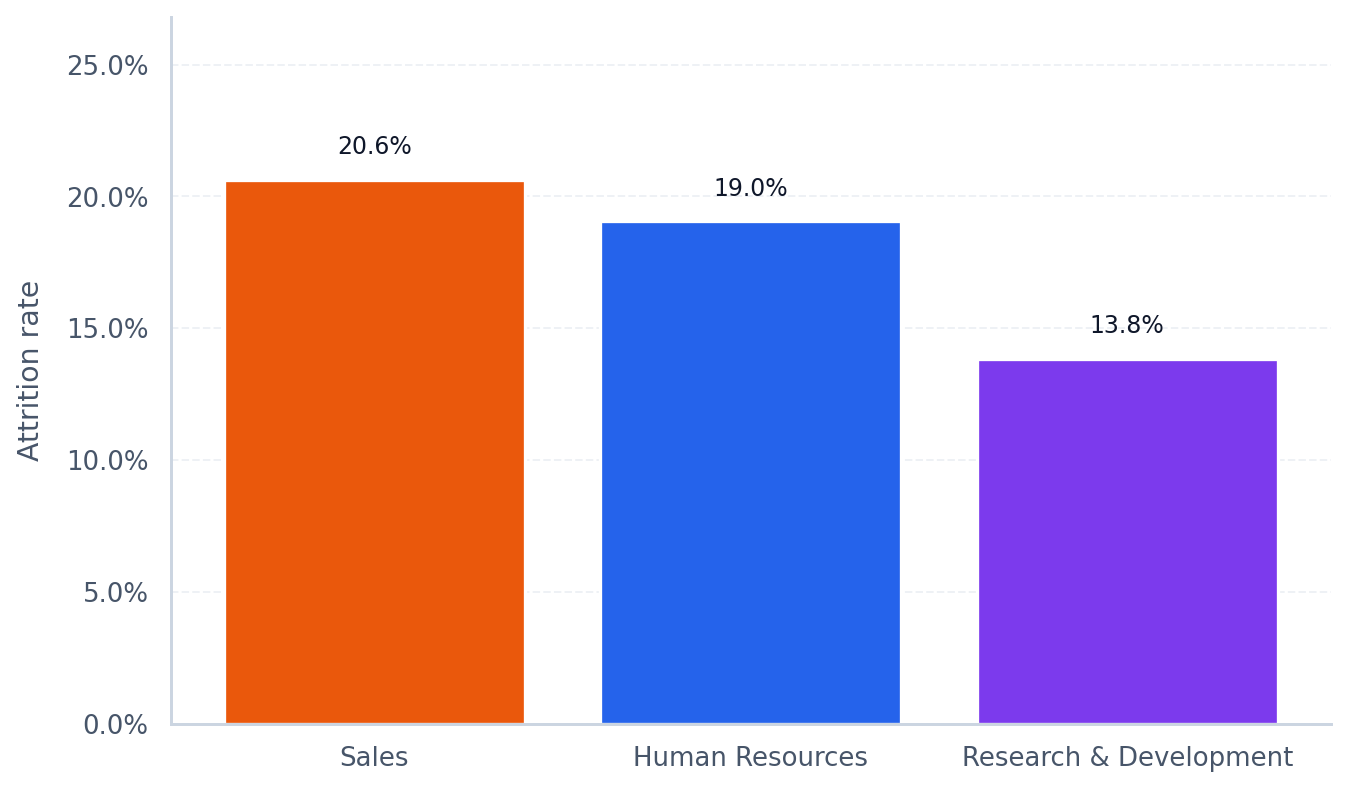

In [6]:
dept_attr = (df.assign(attrition_flag=(df["Attrition"] == "Yes").astype(int))
               .groupby("Department", as_index=False)
               .agg(headcount=("attrition_flag", "size"), attrition_rate=("attrition_flag", "mean"))
               .sort_values("attrition_rate", ascending=False))

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
colors = [THEME["orange"], THEME["blue"], THEME["purple"]][:len(dept_attr)]
ax.bar(dept_attr["Department"], dept_attr["attrition_rate"], color=colors, edgecolor="white", linewidth=1.4)
style_axis(ax, ylabel="Attrition rate", y_percent=True)
ax.set_ylim(0, dept_attr["attrition_rate"].max() * 1.30)
annotate_bars(ax, fmt="{:.1%}")
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Job role mix and attrition rate**

This view keeps scale and risk together by showing role headcount and attrition in the same frame, making it easier to distinguish large roles from high-risk roles.


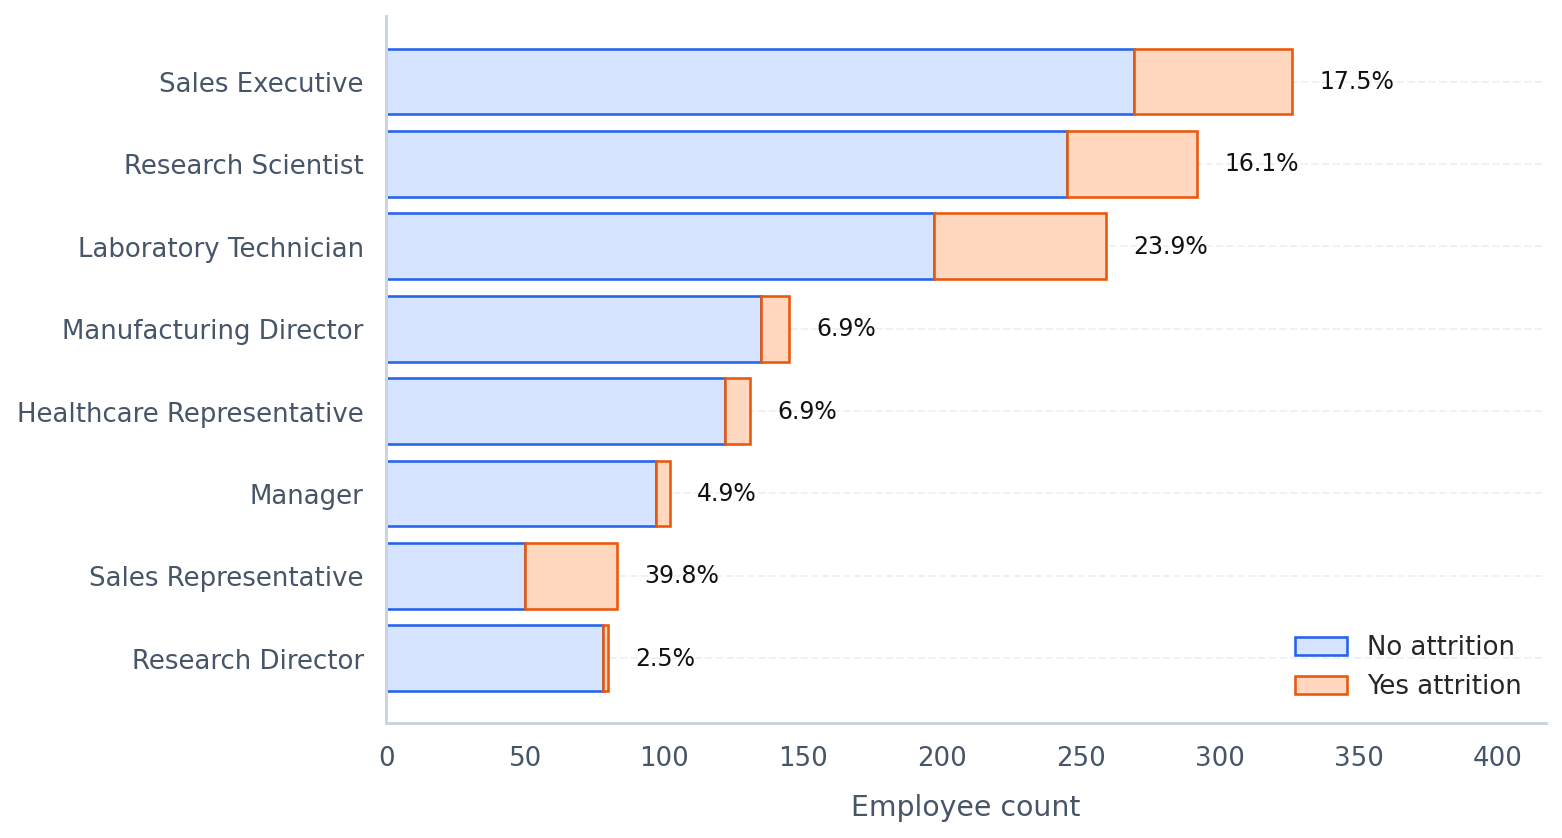

In [7]:
role_mix = (df.assign(attrition_flag=(df["Attrition"] == "Yes").astype(int))
              .groupby(["JobRole", "Attrition"], as_index=False)
              .size()
              .pivot(index="JobRole", columns="Attrition", values="size")
              .fillna(0)
              .reset_index())

role_mix["Headcount"] = role_mix.get("Yes", 0) + role_mix.get("No", 0)
role_mix["AttritionRate"] = role_mix.get("Yes", 0) / role_mix["Headcount"]
role_mix = role_mix.sort_values(["Headcount", "AttritionRate"], ascending=[False, False]).head(8).sort_values("Headcount", ascending=True)

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
ax.barh(role_mix["JobRole"], role_mix.get("No", 0), color=THEME["blue_soft"], edgecolor=THEME["blue"], linewidth=1.1, label="No attrition")
ax.barh(role_mix["JobRole"], role_mix.get("Yes", 0), left=role_mix.get("No", 0), color=THEME["orange_soft"], edgecolor=THEME["orange"], linewidth=1.1, label="Yes attrition")

xmax = role_mix["Headcount"].max()
for i, (_, row) in enumerate(role_mix.iterrows()):
    ax.text(
    row["Headcount"] + xmax * 0.03,
    i,
    f"{row['AttritionRate']:.1%}",
    va="center",
    ha="left",
    fontsize=10,
    color="#111111"
)
style_axis(ax, xlabel="Employee count", ylabel="")
ax.set_xlim(0, xmax * 1.28)
ax.legend(frameon=False, loc="lower right")
fig_card(fig, width=CHART_CARD_WIDTH)

## 5.2 Work pattern and workload

#### **Attrition rate by overtime status**

Overtime is one of the clearest workload signals in the dataset and offers an early indication of where pressure may be strongest.


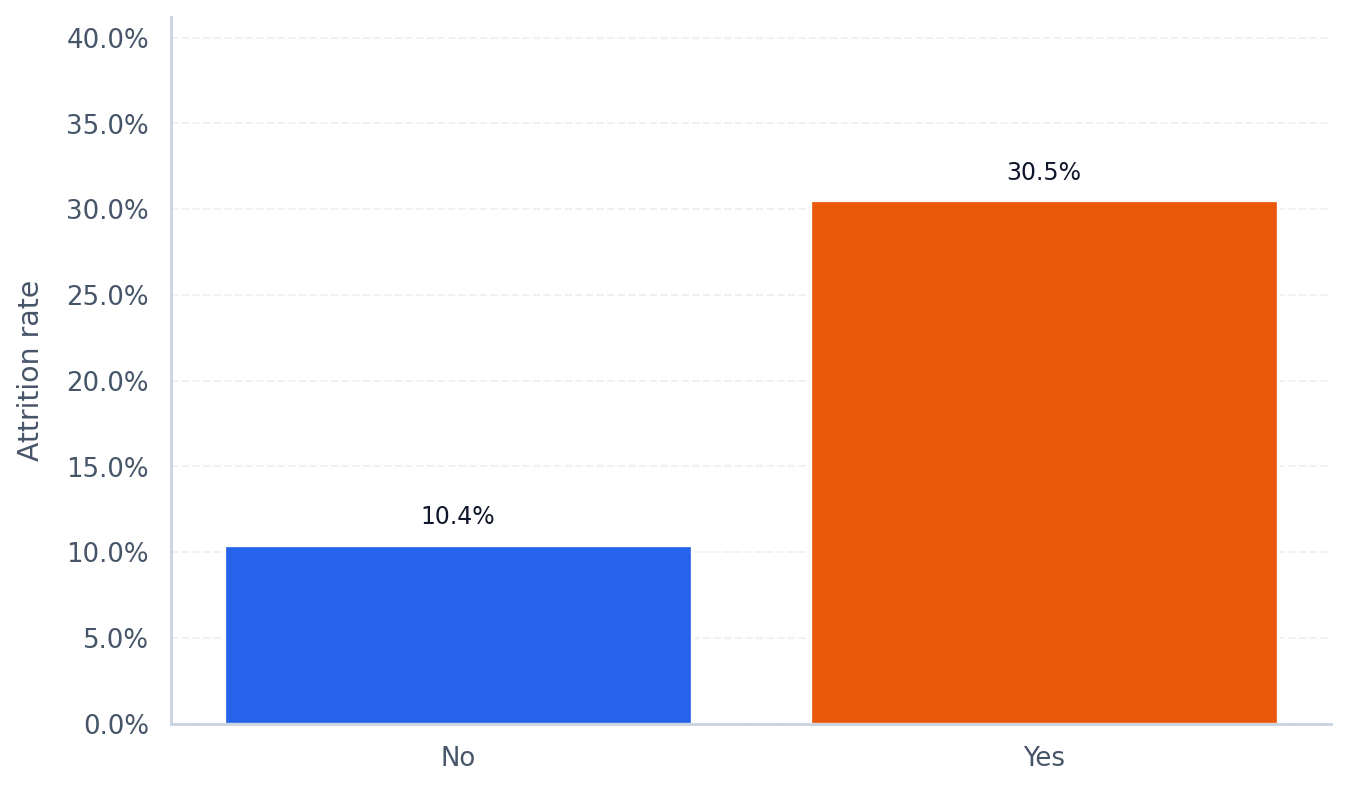

In [8]:
overtime_view = (df.assign(attrition_flag=(df["Attrition"] == "Yes").astype(int))
                   .groupby("OverTime", as_index=False)
                   .agg(headcount=("attrition_flag", "size"), attrition_rate=("attrition_flag", "mean")))

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
ax.bar(overtime_view["OverTime"], overtime_view["attrition_rate"], color=[THEME["blue"], THEME["orange"]], edgecolor="white", linewidth=1.4)
style_axis(ax, ylabel="Attrition rate", y_percent=True)
ax.set_ylim(0, overtime_view["attrition_rate"].max() * 1.35)
annotate_bars(ax, fmt="{:.1%}")
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Income and total working years**

The income-versus-experience view helps separate reward effects from simple tenure effects and shows where attrition remains visible across the curve.


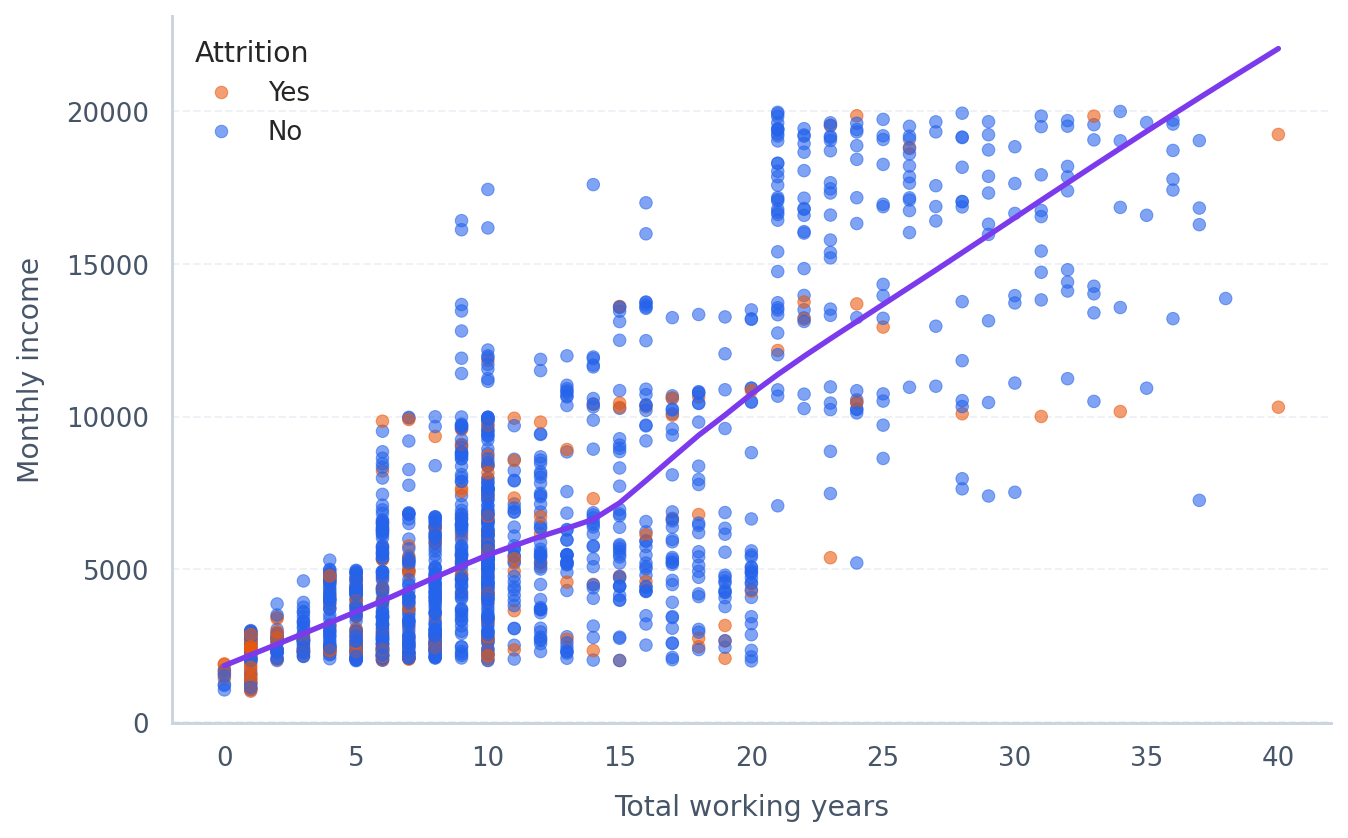

In [9]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
sns.scatterplot(
    data=df, x="TotalWorkingYears", y="MonthlyIncome", hue="Attrition",
    palette={"No": THEME["blue"], "Yes": THEME["orange"]},
    alpha=0.58, s=28, edgecolor=None, ax=ax
)
sns.regplot(
    data=df, x="TotalWorkingYears", y="MonthlyIncome",
    scatter=False, lowess=True, color=THEME["purple"],
    line_kws={"linewidth": 2.3}, ax=ax
)
style_axis(ax, xlabel="Total working years", ylabel="Monthly income")
ax.legend(frameon=False, title="Attrition")
fig_card(fig, width=CHART_CARD_WIDTH)

## 5.3 Compensation and progression

#### **Attrition across tenure bands**

Tenure bands show whether attrition is distributed evenly over time or concentrated in specific stages of the employee lifecycle.


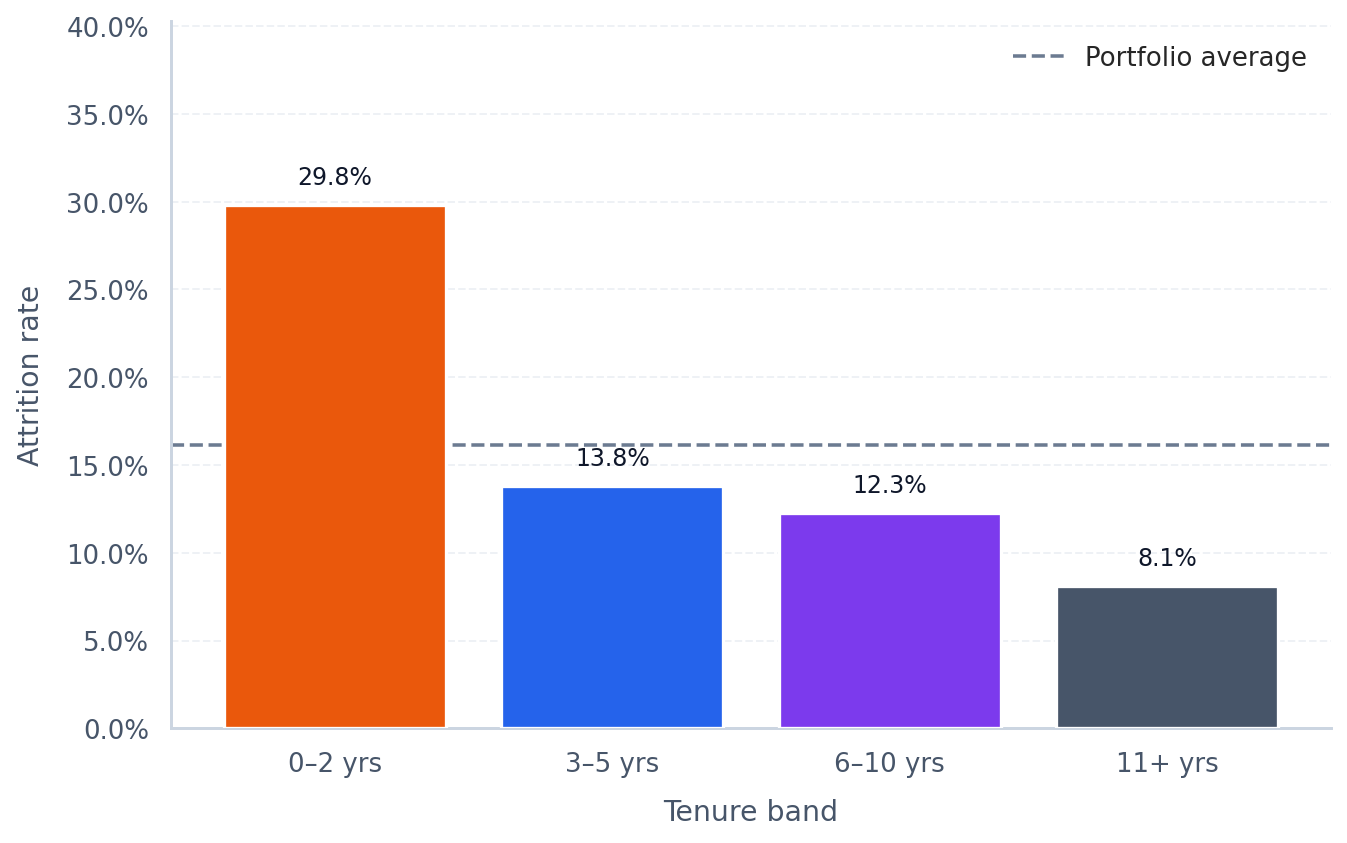

In [10]:
tenure_df = df.copy()
tenure_df["TenureBand"] = pd.cut(
    tenure_df["YearsAtCompany"],
    bins=[-1, 2, 5, 10, 40],
    labels=["0–2 yrs", "3–5 yrs", "6–10 yrs", "11+ yrs"]
)
tenure_view = (
    tenure_df.assign(attrition_flag=(tenure_df["Attrition"] == "Yes").astype(int))
             .groupby("TenureBand", as_index=False, observed=False)["attrition_flag"]
             .mean()
)
overall_attrition = tenure_df["Attrition"].eq("Yes").mean()

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
bars = ax.bar(
    tenure_view["TenureBand"],
    tenure_view["attrition_flag"],
    color=[THEME["orange"], THEME["blue"], THEME["purple"], THEME["slate"]],
    edgecolor="#FFFFFF",
    linewidth=1.4,
    zorder=3
)

ax.axhline(
    overall_attrition,
    linestyle="--",
    linewidth=1.5,
    color=THEME["muted"],
    alpha=0.95,
    label="Portfolio average",
    zorder=2
)

style_axis(ax, xlabel="Tenure band", ylabel="Attrition rate", y_percent=True)
ax.set_ylim(0, tenure_view["attrition_flag"].max() * 1.35)
annotate_bars(ax, fmt="{:.1%}")
ax.legend(frameon=False, loc="upper right")

fig_card(fig, width=CHART_CARD_WIDTH)

#### **Attrition by promotion-lag band**

Promotion timing does not explain exit risk on its own, but it is still a useful friction signal when read alongside workload and reward indicators.


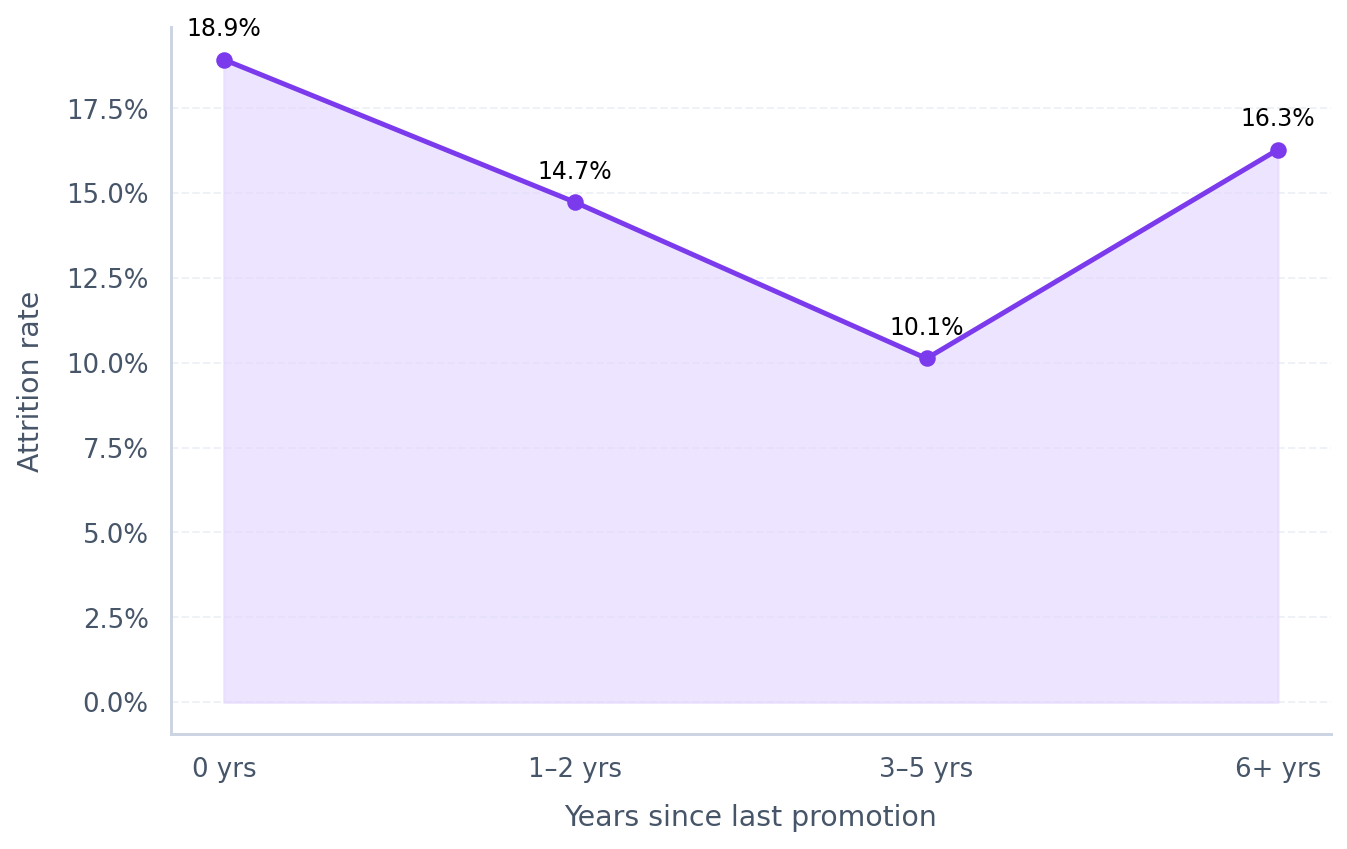

In [11]:
promo_df = df.copy()
promo_df["PromotionLagBand"] = pd.cut(promo_df["YearsSinceLastPromotion"], bins=[-1, 0, 2, 5, 20], labels=["0 yrs", "1–2 yrs", "3–5 yrs", "6+ yrs"])
promo_view = (promo_df.assign(attrition_flag=(promo_df["Attrition"] == "Yes").astype(int))
                      .groupby("PromotionLagBand", as_index=False, observed=False)["attrition_flag"].mean())

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
x = np.arange(len(promo_view))
ax.plot(x, promo_view["attrition_flag"], marker="o", linewidth=2.1, color=THEME["purple"])
ax.fill_between(x, promo_view["attrition_flag"], color=THEME["purple_soft"], alpha=0.65)

for xi, yi in zip(x, promo_view["attrition_flag"]):
    ax.annotate(
        f"{yi:.1%}",
        (xi, yi),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        va="bottom",
        fontsize=10,
        color="black"
    )
    
ax.set_xticks(x); ax.set_xticklabels(promo_view["PromotionLagBand"].astype(str))
style_axis(ax, xlabel="Years since last promotion", ylabel="Attrition rate", y_percent=True)
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Composite experience score by attrition status**

The composite experience view combines several employee-facing signals into one distribution and helps show whether exit cases cluster in weaker experience profiles.


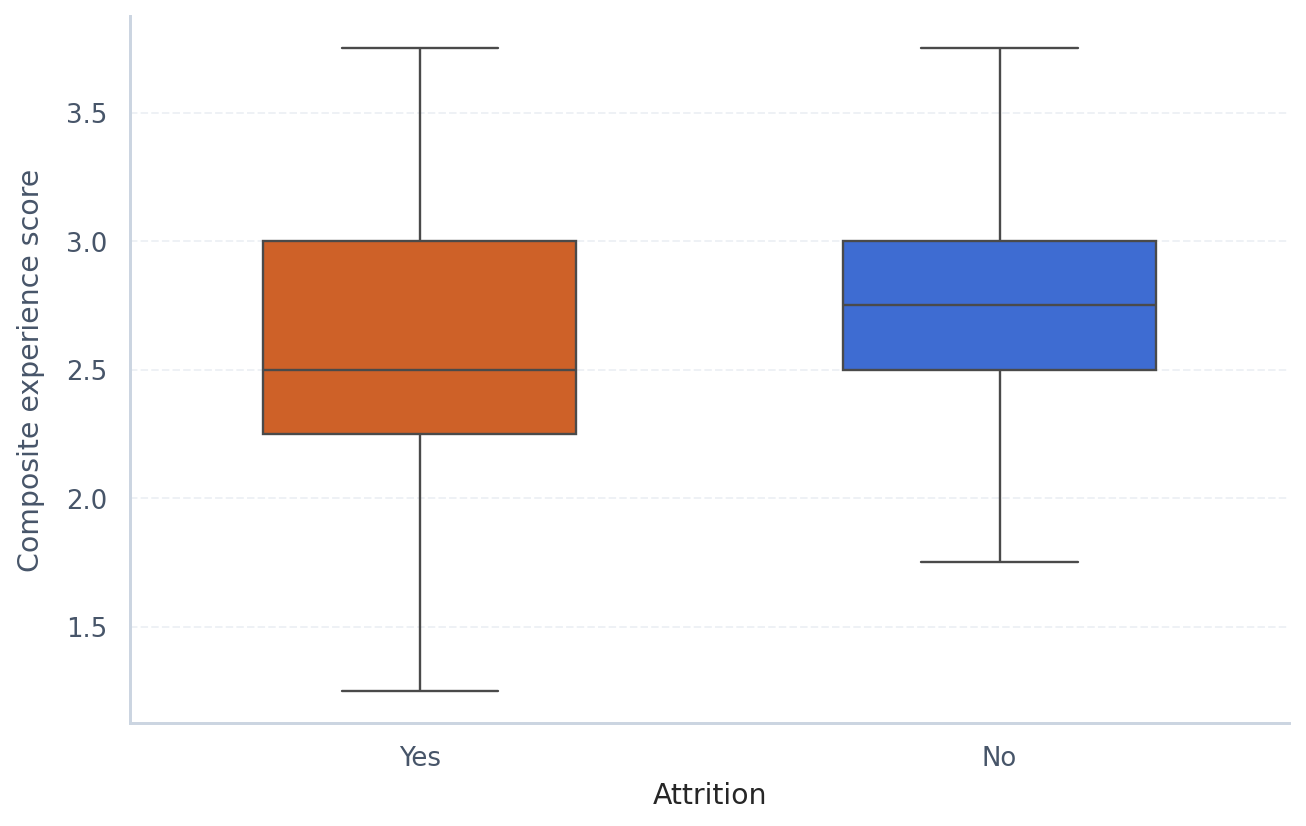

In [12]:
sat_df = df.copy()
sat_df["SatisfactionComposite"] = sat_df[["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]].mean(axis=1)
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
sns.boxplot(data=sat_df, x="Attrition", y="SatisfactionComposite",
            palette={"No": THEME["blue"], "Yes": THEME["orange"]},
            width=0.54, showfliers=False, ax=ax)
style_axis(ax, ylabel="Composite experience score")
fig_card(fig, width=CHART_CARD_WIDTH)

## 5.4 Role and lifecycle detail

#### **Role exposure — attrition rate by job role**

The composite experience view combines several employee-facing signals into one distribution and helps show whether exit cases cluster in weaker experience profiles.


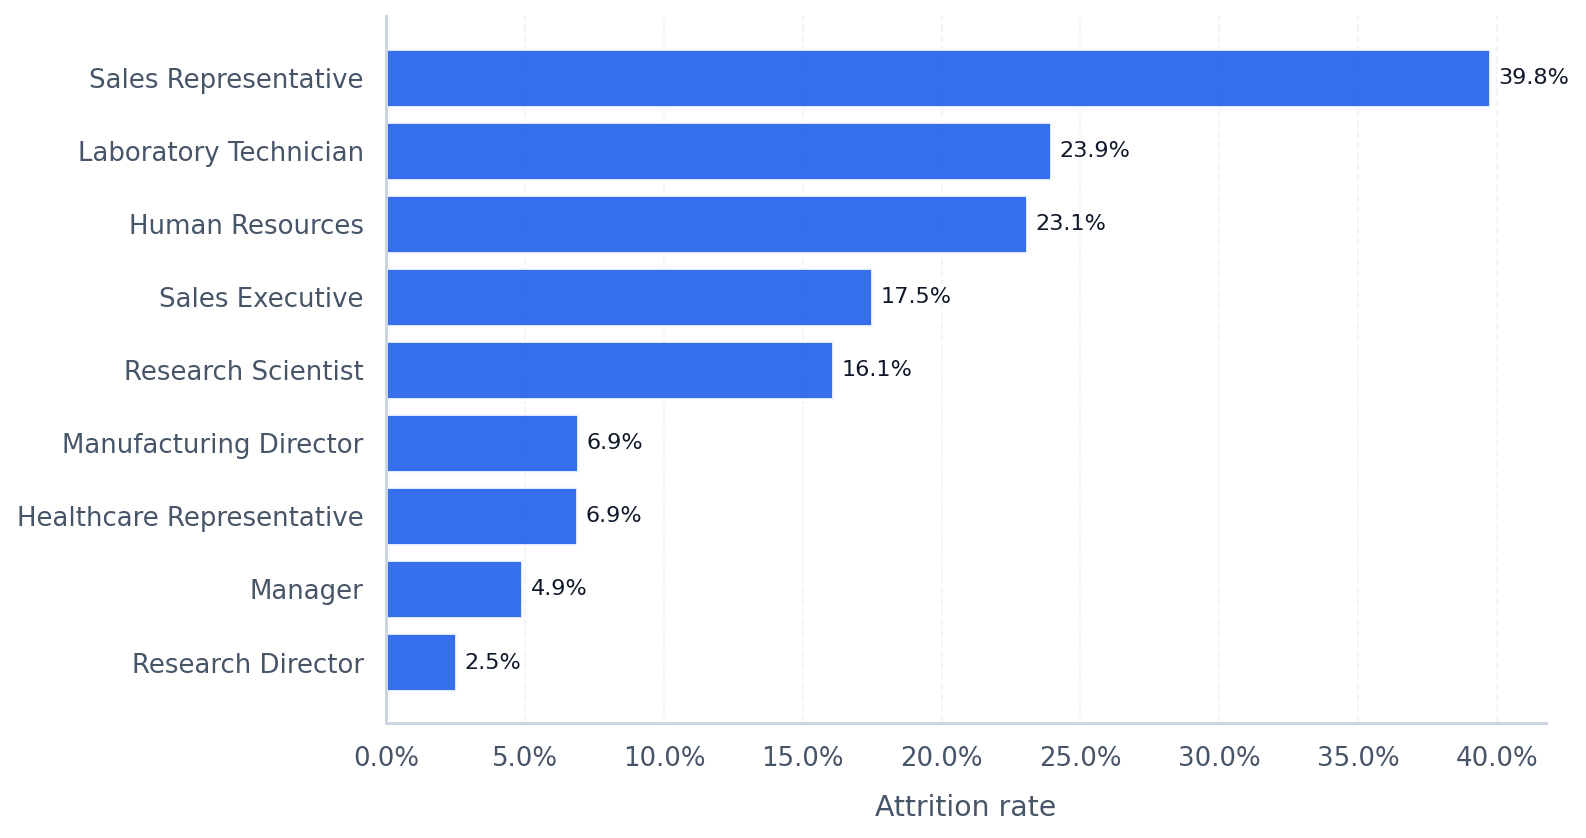

In [13]:
role_attr = (
    df.assign(AttritionFlag=(df["Attrition"] == "Yes").astype(int))
      .groupby("JobRole", as_index=False)
      .agg(
          Headcount=("AttritionFlag", "size"),
          AttritionRate=("AttritionFlag", "mean")
      )
      .sort_values("AttritionRate", ascending=True)
)

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
bars = ax.barh(
    role_attr["JobRole"],
    role_attr["AttritionRate"],
    color=THEME["blue"],
    alpha=0.92,
    edgecolor="white",
    linewidth=1.2
)
for bar, value in zip(bars, role_attr["AttritionRate"]):
    ax.text(value + 0.003, bar.get_y() + bar.get_height() / 2, f"{value:.1%}",
            va="center", ha="left", fontsize=9.5, color=THEME["text"])
style_axis(ax, xlabel="Attrition rate", ylabel="", x_percent=True, xgrid=True)
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Pressure map — age band by overtime**

This cross-view shows where age profile and workload conditions intersect, making pressure pockets easier to spot than in separate charts.


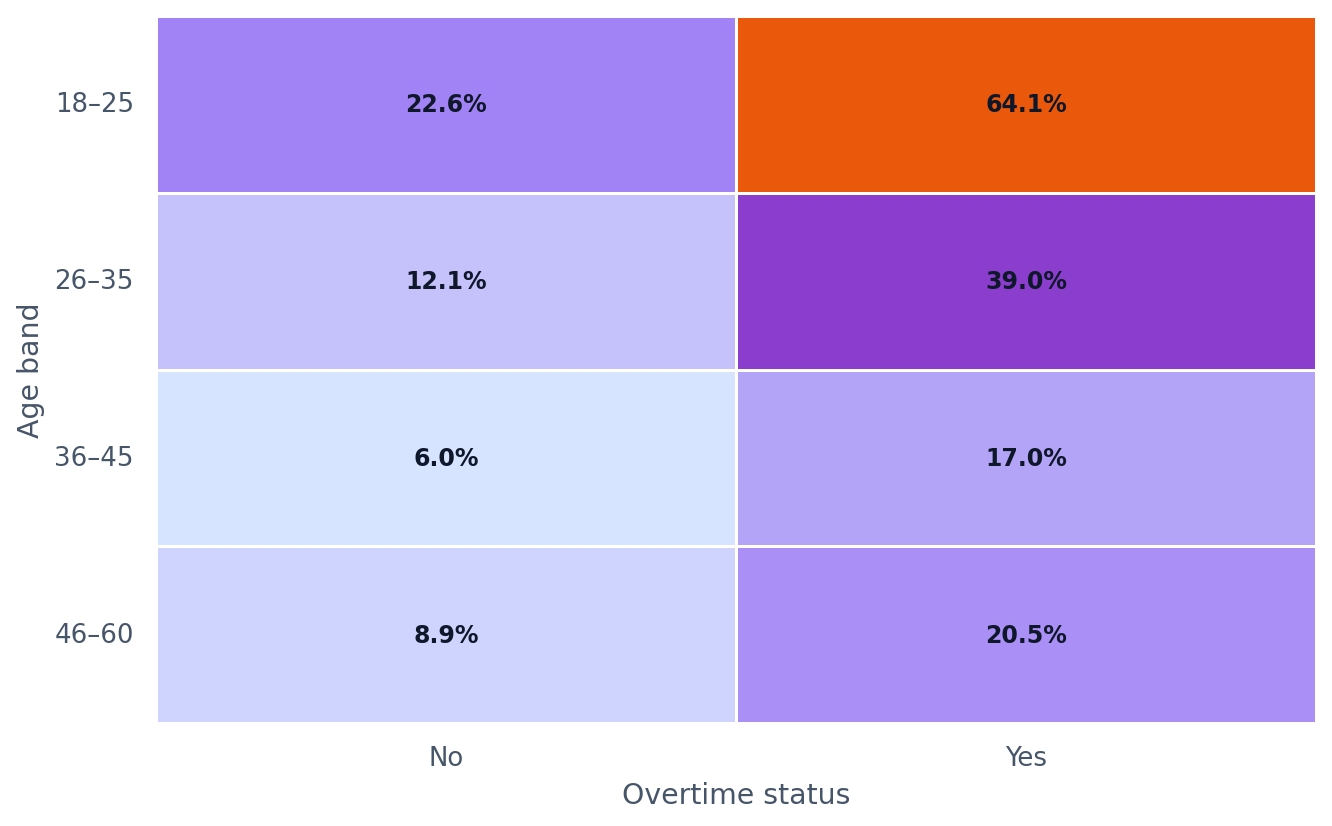

In [14]:
eda_age_ot = df.copy()
eda_age_ot["AttritionFlag"] = (eda_age_ot["Attrition"] == "Yes").astype(int)
eda_age_ot["AgeBand"] = pd.cut(
    eda_age_ot["Age"],
    bins=[17, 25, 35, 45, 60],
    labels=["18–25", "26–35", "36–45", "46–60"]
)

age_ot_heat = (
    eda_age_ot.groupby(["AgeBand", "OverTime"], observed=False)
              .agg(AttritionRate=("AttritionFlag", "mean"))
              .reset_index()
              .pivot(index="AgeBand", columns="OverTime", values="AttritionRate")
              .reindex(["18–25", "26–35", "36–45", "46–60"])
)

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
sns.heatmap(
    age_ot_heat,
    annot=True,
    fmt=".1%",
    cbar=False,
    cmap=LinearSegmentedColormap.from_list(
        "age_ot",
        [THEME["blue_soft"], THEME["purple"], THEME["orange"]]
    ),
    linewidths=1.2,
    linecolor="white",
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": THEME["text"]},
    ax=ax
)
ax.set_xlabel("Overtime status", color=THEME["slate"])
ax.set_ylabel("Age band", color=THEME["slate"])
ax.tick_params(axis="x", rotation=0, colors=THEME["slate"])
ax.tick_params(axis="y", rotation=0, colors=THEME["slate"])
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Compensation view — monthly income by outcome**

The distribution view shows the full spread of compensation levels while keeping the median visible for a cleaner comparison between stay and exit outcomes.


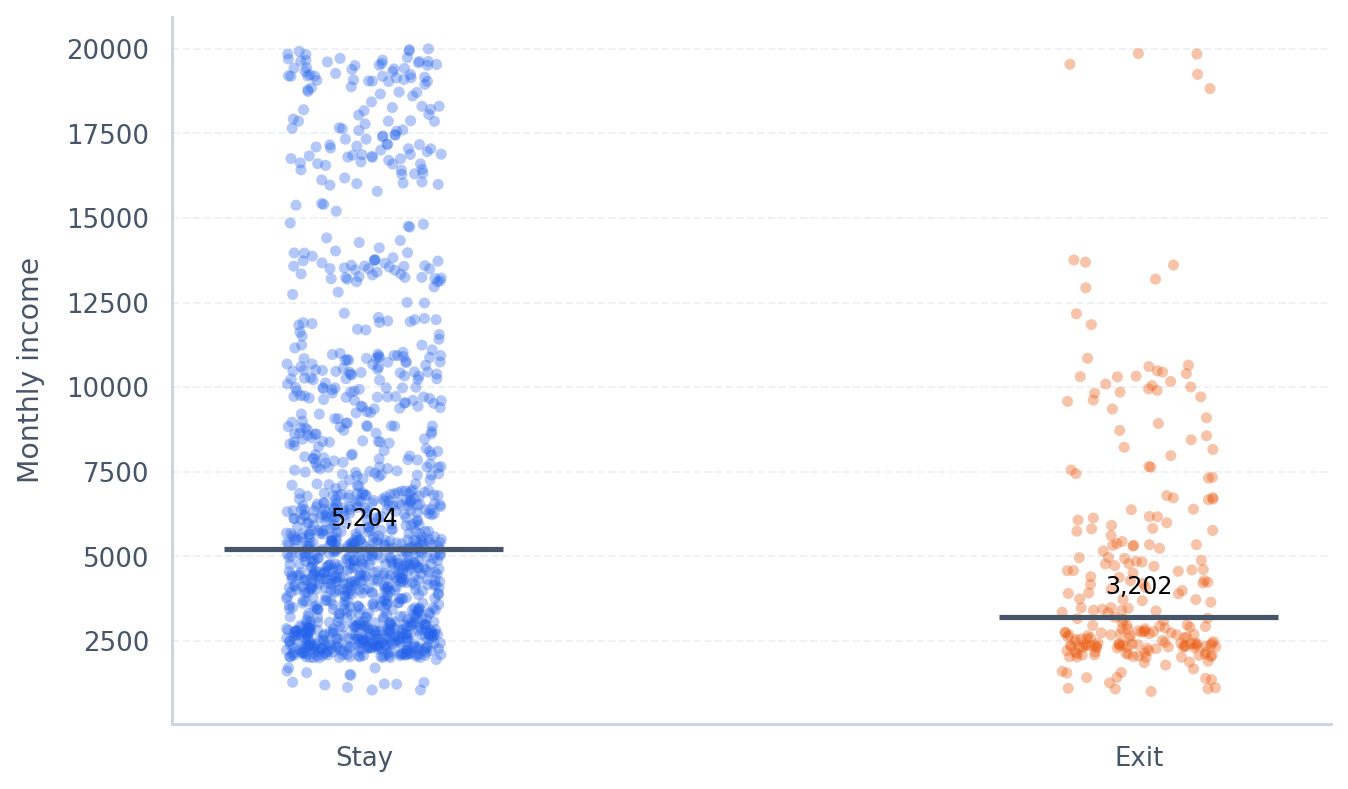

In [15]:
income_box = df[["Attrition", "MonthlyIncome"]].copy()

stay_income = income_box.loc[income_box["Attrition"] == "No", "MonthlyIncome"].to_numpy()
exit_income = income_box.loc[income_box["Attrition"] == "Yes", "MonthlyIncome"].to_numpy()

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)

rng = np.random.default_rng(42)
x_stay = 1 + rng.uniform(-0.10, 0.10, size=len(stay_income))
x_exit = 2 + rng.uniform(-0.10, 0.10, size=len(exit_income))

ax.scatter(
    x_stay, stay_income,
    s=22, alpha=0.35,
    color=THEME["blue"],
    edgecolors="none",
    label="Stay"
)
ax.scatter(
    x_exit, exit_income,
    s=22, alpha=0.35,
    color=THEME["orange"],
    edgecolors="none",
    label="Exit"
)

stay_median = np.median(stay_income)
exit_median = np.median(exit_income)

ax.hlines(stay_median, 0.82, 1.18, color=THEME["slate"], linewidth=2.2)
ax.hlines(exit_median, 1.82, 2.18, color=THEME["slate"], linewidth=2.2)

ax.annotate(
    f"{stay_median:,.0f}",
    (1, stay_median),
    textcoords="offset points",
    xytext=(0, 8),
    ha="center",
    va="bottom",
    fontsize=10,
    color="black"
)
ax.annotate(
    f"{exit_median:,.0f}",
    (2, exit_median),
    textcoords="offset points",
    xytext=(0, 8),
    ha="center",
    va="bottom",
    fontsize=10,
    color="black"
)

ax.set_xticks([1, 2])
ax.set_xticklabels(["Stay", "Exit"])

style_axis(ax, xlabel="", ylabel="Monthly income")
fig_card(fig, width=CHART_CARD_WIDTH)

<a id="6-workforce-segmentation--executive-scorecards"></a>

# 6. 🧾 Workforce Segmentation & Executive Scorecards

This section converts raw employee records into management-ready scorecards. The aim is not only to describe the workforce, but to identify where pressure seems to cluster across departments, roles, career stages, and workload combinations.

In [16]:
df_seg = df.copy()
df_seg["AttritionFlag"] = (df_seg["Attrition"] == "Yes").astype(int)
df_seg["CareerStage"] = pd.cut(
    df_seg["TotalWorkingYears"],
    bins=[-1, 3, 8, 15, 50],
    labels=["Early Career", "Mid Career", "Established", "Long-Tenure"]
)
df_seg["OvertimeFlag"] = (df_seg["OverTime"] == "Yes").astype(int)
df_seg["LowWorkLifeFlag"] = (df_seg["WorkLifeBalance"] <= 2).astype(int)

dept_scorecard = (
    df_seg.groupby("Department", as_index=False)
          .agg(
              Headcount=("AttritionFlag", "size"),
              AttritionRate=("AttritionFlag", "mean"),
              AvgIncome=("MonthlyIncome", "mean"),
              AvgYearsAtCompany=("YearsAtCompany", "mean"),
              OvertimeShare=("OvertimeFlag", "mean")
          )
          .sort_values("AttritionRate", ascending=False)
)

role_scorecard = (
    df_seg.groupby("JobRole", as_index=False)
          .agg(
              Headcount=("AttritionFlag", "size"),
              AttritionRate=("AttritionFlag", "mean"),
              AvgIncome=("MonthlyIncome", "mean"),
              AvgYearsAtCompany=("YearsAtCompany", "mean"),
              AvgPromotionLag=("YearsSinceLastPromotion", "mean")
          )
          .sort_values(["AttritionRate", "Headcount"], ascending=[False, False])
)

career_scorecard = (
    df_seg.groupby("CareerStage", as_index=False, observed=False)
          .agg(
              Headcount=("AttritionFlag", "size"),
              AttritionRate=("AttritionFlag", "mean"),
              AvgIncome=("MonthlyIncome", "mean"),
              AvgWorkingYears=("TotalWorkingYears", "mean")
          )
          .sort_values("AttritionRate", ascending=False)
)

risk_cluster = (
    df_seg.groupby(["OvertimeFlag", "LowWorkLifeFlag"], as_index=False)
          .agg(
              Headcount=("AttritionFlag", "size"),
              AttritionRate=("AttritionFlag", "mean")
          )
)

df_tabs([
    ("Department", dept_scorecard, 2, 20),
    ("Job Role", role_scorecard, 2, 20),
    ("Career Stage", career_scorecard, 2, 20),
], panel_title="Executive Scorecards")

,Department,Headcount,AttritionRate,AvgIncome,AvgYearsAtCompany,OvertimeShare
2,Sales,446,20.6%,"6,959",7.28,28.7%
0,Human Resources,63,19.0%,"6,655",7.24,27.0%
1,Research & Development,961,13.8%,"6,281",6.86,28.2%
,JobRole,Headcount,AttritionRate,AvgIncome,AvgYearsAtCompany,AvgPromotionLag
8,Sales Representative,83,39.8%,"2,626",2.92,1.06
2,Laboratory Technician,259,23.9%,"3,237",5.02,1.42
1,Human Resources,52,23.1%,"4,236",5.33,1.27
7,Sales Executive,326,17.5%,"6,924",7.50,2.48
6,Research Scientist,292,16.1%,"3,240",5.11,1.51
4,Manufacturing Director,145,6.9%,"7,295",7.60,2.12


#### **Workload cluster heatmap**

The heatmap brings workload and work-life balance together so the interaction between strain and attrition is visible at a segment level.


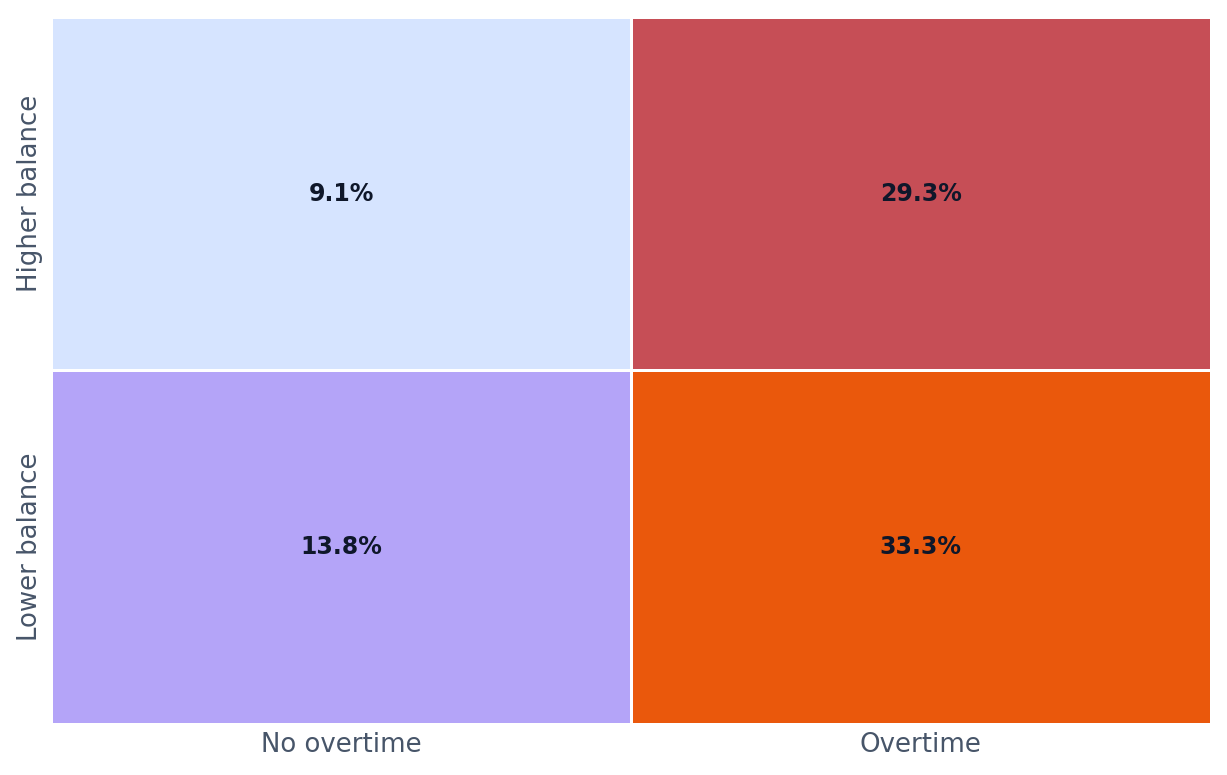

In [17]:
cluster_pivot = risk_cluster.pivot(index="LowWorkLifeFlag", columns="OvertimeFlag", values="AttritionRate")
cluster_pivot.index = ["Higher balance", "Lower balance"]
cluster_pivot.columns = ["No overtime", "Overtime"]

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
sns.heatmap(
    cluster_pivot,
    annot=True,
    fmt=".1%",
    cbar=False,
    cmap=LinearSegmentedColormap.from_list(
        "risk_map",
        [THEME["blue_soft"], THEME["purple"], THEME["orange"]]
    ),
    linewidths=1.2,
    linecolor="white",
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": THEME["text"]},
    ax=ax
)
ax.tick_params(colors=THEME["slate"], length=0)
fig_card(fig, width=CHART_CARD_WIDTH)

<a id="7-feature-engineering--people-risk-signals"></a>

# 7. 🏗️ Feature Engineering — People Risk Signals

The next step translates raw HR fields into more decision-relevant signals that better reflect workload, progression, experience, reward, and mobility pressure.

In [18]:
df_fe = df.copy()

df_fe["AttritionFlag"] = (df_fe["Attrition"] == "Yes").astype(int)
df_fe["AgeBand"] = pd.cut(df_fe["Age"], bins=[17, 25, 35, 45, 60], labels=["18–25", "26–35", "36–45", "46–60"])
df_fe["TenureBand"] = pd.cut(df_fe["YearsAtCompany"], bins=[-1, 2, 5, 10, 40], labels=["0–2 yrs", "3–5 yrs", "6–10 yrs", "11+ yrs"])
df_fe["IncomeBand"] = pd.qcut(df_fe["MonthlyIncome"], q=4, labels=["Q1 Low", "Q2", "Q3", "Q4 High"], duplicates="drop")
df_fe["PromotionLagBand"] = pd.cut(df_fe["YearsSinceLastPromotion"], bins=[-1, 0, 2, 5, 20], labels=["0 yrs", "1–2 yrs", "3–5 yrs", "6+ yrs"])

df_fe["OvertimeFlag"] = (df_fe["OverTime"] == "Yes").astype(int)
df_fe["LongCommuteFlag"] = (df_fe["DistanceFromHome"] >= 15).astype(int)
df_fe["EarlyCareerFlag"] = (df_fe["TotalWorkingYears"] <= 3).astype(int)
df_fe["LowWorkLifeFlag"] = (df_fe["WorkLifeBalance"] <= 2).astype(int)

df_fe["SatisfactionComposite"] = df_fe[
    ["JobSatisfaction", "EnvironmentSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]
].mean(axis=1)

df_fe["CareerFrictionScore"] = (
    (df_fe["YearsSinceLastPromotion"] >= 3).astype(int)
    + (df_fe["YearsInCurrentRole"] >= 5).astype(int)
    + (df_fe["YearsWithCurrManager"] >= 5).astype(int)
)

df_fe["WorkloadPressureScore"] = (
    df_fe["OvertimeFlag"] + df_fe["LongCommuteFlag"] + df_fe["LowWorkLifeFlag"]
)

df_fe["IncomePerLevel"] = df_fe["MonthlyIncome"] / df_fe["JobLevel"].replace(0, np.nan)
df_fe["YearsPerCompanyRatio"] = df_fe["YearsAtCompany"] / (df_fe["TotalWorkingYears"].replace(0, np.nan) + 1)
df_fe["PromotionStallIntensity"] = df_fe["YearsSinceLastPromotion"] / (df_fe["YearsAtCompany"] + 1)
df_fe["TravelOvertimeInteraction"] = (
    df_fe["OvertimeFlag"] * df_fe["BusinessTravel"].map({"Non-Travel": 0, "Travel_Rarely": 1, "Travel_Frequently": 2}).fillna(0)
)

df_fe["RiskSegment"] = np.select(
    [
        (df_fe["OvertimeFlag"] == 1) & (df_fe["LowWorkLifeFlag"] == 1),
        (df_fe["EarlyCareerFlag"] == 1) & (df_fe["MonthlyIncome"] <= df_fe["MonthlyIncome"].median()),
        (df_fe["CareerFrictionScore"] >= 2)
    ],
    ["Workload Pressure", "Early Career Pay Pressure", "Career Friction"],
    default="Broader Workforce"
)

feature_catalogue = pd.DataFrame({
    "Feature": [
        "AgeBand", "TenureBand", "IncomeBand", "PromotionLagBand",
        "OvertimeFlag", "LongCommuteFlag", "EarlyCareerFlag", "LowWorkLifeFlag",
        "SatisfactionComposite", "CareerFrictionScore", "WorkloadPressureScore",
        "IncomePerLevel", "YearsPerCompanyRatio", "PromotionStallIntensity",
        "TravelOvertimeInteraction", "RiskSegment"
    ],
    "Type": [
        "Band", "Band", "Band", "Band",
        "Binary", "Binary", "Binary", "Binary",
        "Composite", "Composite", "Composite",
        "Ratio", "Ratio", "Ratio",
        "Interaction", "Segment"
    ],
    "Purpose": [
        "Career life stage reading",
        "Tenure concentration reading",
        "Relative reward positioning",
        "Progression pacing view",
        "Visible workload signal",
        "Travel / commute load proxy",
        "Earlier-tenure exposure flag",
        "Pressure marker for balance",
        "Experience and sentiment layer",
        "Promotion / role stagnation lens",
        "Combined workload intensity score",
        "Reward scaled by job level",
        "Internal tenure intensity view",
        "Promotion waiting intensity",
        "Travel load under overtime",
        "Actionable risk grouping for HR review"
    ]
})

feature_preview = df_fe[[
    "Attrition", "AgeBand", "TenureBand", "IncomeBand", "PromotionLagBand",
    "OvertimeFlag", "LongCommuteFlag", "EarlyCareerFlag", "LowWorkLifeFlag",
    "SatisfactionComposite", "CareerFrictionScore", "WorkloadPressureScore",
    "IncomePerLevel", "YearsPerCompanyRatio", "PromotionStallIntensity",
    "TravelOvertimeInteraction", "RiskSegment"
]].head(10).copy()

df_tabs([
    ("Feature Catalogue", feature_catalogue, 0, 20),
    ("Feature Preview", feature_preview, 2, 10),
], panel_title="Feature Layer")

,Feature,Type,Purpose
0,AgeBand,Band,Career life stage reading
1,TenureBand,Band,Tenure concentration reading
2,IncomeBand,Band,Relative reward positioning
3,PromotionLagBand,Band,Progression pacing view
4,OvertimeFlag,Binary,Visible workload signal
5,LongCommuteFlag,Binary,Travel / commute load proxy
6,EarlyCareerFlag,Binary,Earlier-tenure exposure flag
7,LowWorkLifeFlag,Binary,Pressure marker for balance
8,SatisfactionComposite,Composite,Experience and sentiment layer
9,CareerFrictionScore,Composite,Promotion / role stagnation lens


<a id="8-modelling--attrition-risk-classification"></a>

# 8. 🤖 Modelling — Attrition Risk Classification

The modelling layer is organized around a balanced operating objective. The benchmark does not chase a single headline score. Instead, it weighs discrimination, threshold behavior, calibration discipline, and practical usability together.

Three guardrails drive the design:

- keep the signal set readable and avoid circular risk proxies,
- benchmark a small model family rather than an overly broad search,
- separate **model selection** from **operating-threshold selection** so governance stays clear.

In [19]:
model_signal_cols = [
    "Age", "BusinessTravel", "Department", "DistanceFromHome", "EducationField",
    "EnvironmentSatisfaction", "JobInvolvement", "JobLevel", "JobRole",
    "JobSatisfaction", "MaritalStatus", "MonthlyIncome", "NumCompaniesWorked",
    "OverTime", "PercentSalaryHike", "RelationshipSatisfaction", "StockOptionLevel",
    "TotalWorkingYears", "TrainingTimesLastYear", "WorkLifeBalance", "YearsAtCompany",
    "YearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager",
    "AgeBand", "TenureBand", "IncomeBand", "PromotionLagBand", "OvertimeFlag",
    "SatisfactionComposite", "CareerFrictionScore", "WorkloadPressureScore"
]

X = df_fe[model_signal_cols].copy()
y = df_fe["AttritionFlag"].copy()

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]),
            numeric_features,
        ),
        (
            "cat",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]),
            categorical_features,
        ),
    ],
    sparse_threshold=0,
)


def expected_calibration_error(y_true, proba, n_bins=5):
    y_true = np.asarray(y_true)
    proba = np.asarray(proba)
    bins = np.linspace(0, 1, n_bins + 1)
    bin_ids = np.digitize(proba, bins[1:-1], right=True)
    total = max(len(proba), 1)
    ece = 0.0

    for bin_idx in range(n_bins):
        mask = bin_ids == bin_idx
        if mask.any():
            ece += abs(y_true[mask].mean() - proba[mask].mean()) * (mask.sum() / total)

    return float(ece)

sparse_logistic = Pipeline([
    (
        "pre",
        preprocessor,
    ),
    (
        "select",
        SelectFromModel(
            LogisticRegression(
                max_iter=5000,
                penalty="l1",
                solver="liblinear",
                C=0.18,
                random_state=42,
            )
        ),
    ),
    (
        "model",
        LogisticRegression(
            max_iter=5000,
            C=0.55,
            random_state=42,
        ),
    ),
])

stable_sparse_logistic = CalibratedClassifierCV(
    estimator=sparse_logistic,
    method="sigmoid",
    cv=4,
)

positive_count = max(int(y.sum()), 1)
negative_count = max(int((1 - y).sum()), 1)
imbalance_ratio = negative_count / positive_count

try:
    from xgboost import XGBClassifier

    probability_tree_name = "XGBoost + Sigmoid"
    probability_tree_base = Pipeline([
        ("pre", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=280,
                learning_rate=0.045,
                max_depth=3,
                min_child_weight=2,
                subsample=0.90,
                colsample_bytree=0.85,
                reg_alpha=0.08,
                reg_lambda=1.20,
                gamma=0.00,
                scale_pos_weight=imbalance_ratio,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ])
except Exception:
    probability_tree_name = "Extra Trees + Sigmoid"
    probability_tree_base = Pipeline([
        ("pre", preprocessor),
        (
            "model",
            ExtraTreesClassifier(
                n_estimators=420,
                max_depth=10,
                min_samples_leaf=4,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ])

probability_tree = CalibratedClassifierCV(
    estimator=probability_tree_base,
    method="sigmoid",
    cv=4,
)

models = {
    "Sparse Logistic": sparse_logistic,
    "Sparse Logistic + Sigmoid": stable_sparse_logistic,
    probability_tree_name: probability_tree,
}

probability_profile_map = {
    "Sparse Logistic": "Stable raw score",
    "Sparse Logistic + Sigmoid": "Sigmoid calibrated",
    probability_tree_name: "Sigmoid calibrated",
}

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42,
)

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)


def build_threshold_table(y_true, proba):
    rows = []
    target_flag_rate = float(np.clip(np.mean(y_true) * 1.30, 0.11, 0.24))

    for threshold in np.round(np.arange(0.08, 0.56, 0.02), 2):
        pred = (proba >= threshold).astype(int)
        precision = precision_score(y_true, pred, zero_division=0)
        recall = recall_score(y_true, pred, zero_division=0)
        balanced_acc = balanced_accuracy_score(y_true, pred)
        f1 = f1_score(y_true, pred, zero_division=0)
        f1_5 = fbeta_score(y_true, pred, beta=1.5, zero_division=0)
        flag_rate = pred.mean()
        precision_recall_gap = abs(precision - recall)

        operating_score = (
            0.24 * f1
            + 0.18 * balanced_acc
            + 0.16 * precision
            + 0.16 * recall
            + 0.10 * f1_5
            + 0.08 * min(precision, recall)
            + 0.04 * (1 - precision_recall_gap)
            - 0.08 * abs(flag_rate - target_flag_rate)
        )

        rows.append({
            "Threshold": threshold,
            "Accuracy": accuracy_score(y_true, pred),
            "BalancedAccuracy": balanced_acc,
            "Precision": precision,
            "Recall": recall,
            "F1": f1,
            "F1_5": f1_5,
            "FlagRate": flag_rate,
            "PrecisionRecallGap": precision_recall_gap,
            "OperatingScore": operating_score,
        })

    threshold_df = pd.DataFrame(rows)

    eligible = threshold_df[
        (threshold_df["Precision"] >= 0.45)
        & (threshold_df["Recall"] >= 0.50)
    ].copy()

    if eligible.empty:
        eligible = threshold_df[
            (threshold_df["Precision"] >= 0.42)
            & (threshold_df["Recall"] >= 0.46)
        ].copy()

    if eligible.empty:
        eligible = threshold_df.copy()

    best_row = eligible.sort_values(
        ["OperatingScore", "F1", "BalancedAccuracy", "Precision", "Recall"],
        ascending=False,
    ).iloc[0]

    threshold_df = threshold_df.sort_values(
        ["OperatingScore", "F1", "BalancedAccuracy", "Precision", "Recall"],
        ascending=False,
    ).reset_index(drop=True)

    return threshold_df, float(best_row["Threshold"]), target_flag_rate


benchmark_rows = []
trained_models = {}
threshold_tables = {}
oof_prob_map = {}

for model_name, model in models.items():
    oof_proba = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
    )[:, 1]

    threshold_table, chosen_threshold, target_flag_rate = build_threshold_table(y_train, oof_proba)
    oof_pred_tuned = (oof_proba >= chosen_threshold).astype(int)

    cv_precision = precision_score(y_train, oof_pred_tuned, zero_division=0)
    cv_recall = recall_score(y_train, oof_pred_tuned, zero_division=0)
    cv_balanced_acc = balanced_accuracy_score(y_train, oof_pred_tuned)
    cv_f1 = f1_score(y_train, oof_pred_tuned, zero_division=0)
    cv_f1_5 = fbeta_score(y_train, oof_pred_tuned, beta=1.5, zero_division=0)
    cv_brier = brier_score_loss(y_train, oof_proba)
    cv_ece = expected_calibration_error(y_train, oof_proba, n_bins=5)

    selection_score = (
        0.25 * average_precision_score(y_train, oof_proba)
        + 0.19 * roc_auc_score(y_train, oof_proba)
        + 0.16 * cv_f1
        + 0.12 * cv_balanced_acc
        + 0.10 * min(cv_precision, cv_recall)
        + 0.08 * cv_f1_5
        - 0.06 * abs(cv_precision - cv_recall)
        - 0.08 * cv_brier
        - 0.08 * cv_ece
    )

    model.fit(X_train, y_train)
    test_proba = model.predict_proba(X_test)[:, 1]
    pred_default = (test_proba >= 0.50).astype(int)
    pred_tuned = (test_proba >= chosen_threshold).astype(int)
    test_ece = expected_calibration_error(y_test, test_proba, n_bins=5)

    benchmark_rows.append({
        "Model": model_name,
        "SignalsUsed": len(model_signal_cols),
        "ProbabilityProfile": probability_profile_map.get(model_name, "Standard"),
        "CV_ROC_AUC": roc_auc_score(y_train, oof_proba),
        "CV_PR_AUC": average_precision_score(y_train, oof_proba),
        "CV_BalancedAcc": cv_balanced_acc,
        "CV_F1@Tune": cv_f1,
        "CV_ECE5": cv_ece,
        "TuneThreshold": chosen_threshold,
        "SelectionScore": selection_score,
        "Test_ROC_AUC": roc_auc_score(y_test, test_proba),
        "Test_PR_AUC": average_precision_score(y_test, test_proba),
        "Test_BalancedAcc": balanced_accuracy_score(y_test, pred_tuned),
        "Precision@Tune": precision_score(y_test, pred_tuned, zero_division=0),
        "Recall@Tune": recall_score(y_test, pred_tuned, zero_division=0),
        "F1@Tune": f1_score(y_test, pred_tuned, zero_division=0),
        "Test_ECE5": test_ece,
        "FlagRate@Tune": pred_tuned.mean(),
        "BrierLoss": brier_score_loss(y_test, test_proba),
    })

    trained_models[model_name] = {
        "model": model,
        "proba": test_proba,
        "pred_default": pred_default,
        "pred_tuned": pred_tuned,
        "threshold": chosen_threshold,
        "target_flag_rate": target_flag_rate,
        "cv_ece": cv_ece,
        "test_ece": test_ece,
    }
    threshold_tables[model_name] = threshold_table
    oof_prob_map[model_name] = oof_proba

benchmark_df = (
    pd.DataFrame(benchmark_rows)
    .sort_values(
        ["SelectionScore", "CV_PR_AUC", "CV_BalancedAcc", "Test_ECE5"],
        ascending=[False, False, False, True],
    )
    .reset_index(drop=True)
)

champion_name = benchmark_df.loc[0, "Model"]
champion_model = trained_models[champion_name]["model"]
champion_proba = trained_models[champion_name]["proba"]
champion_pred_default = trained_models[champion_name]["pred_default"]
best_threshold = float(trained_models[champion_name]["threshold"])
champion_pred_tuned = trained_models[champion_name]["pred_tuned"]
target_flag_rate = float(trained_models[champion_name]["target_flag_rate"])
champion_cv_ece = float(trained_models[champion_name]["cv_ece"])
champion_test_ece = float(trained_models[champion_name]["test_ece"])

threshold_df = threshold_tables[champion_name].copy()

threshold_compare_df = pd.DataFrame([
    {
        "OperatingPoint": "Default 0.50",
        "Threshold": 0.50,
        "Accuracy": accuracy_score(y_test, champion_pred_default),
        "BalancedAccuracy": balanced_accuracy_score(y_test, champion_pred_default),
        "Precision": precision_score(y_test, champion_pred_default, zero_division=0),
        "Recall": recall_score(y_test, champion_pred_default, zero_division=0),
        "F1": f1_score(y_test, champion_pred_default, zero_division=0),
        "FlagRate": champion_pred_default.mean(),
    },
    {
        "OperatingPoint": "Balanced tune",
        "Threshold": best_threshold,
        "Accuracy": accuracy_score(y_test, champion_pred_tuned),
        "BalancedAccuracy": balanced_accuracy_score(y_test, champion_pred_tuned),
        "Precision": precision_score(y_test, champion_pred_tuned, zero_division=0),
        "Recall": recall_score(y_test, champion_pred_tuned, zero_division=0),
        "F1": f1_score(y_test, champion_pred_tuned, zero_division=0),
        "FlagRate": champion_pred_tuned.mean(),
    },
])

prob_true, prob_pred = calibration_curve(
    y_test,
    champion_proba,
    n_bins=5,
    strategy="quantile",
)
calibration_df = pd.DataFrame({
    "Bin": [f"Bin {i}" for i in range(1, len(prob_true) + 1)],
    "MeanPredictedRisk": prob_pred,
    "ObservedAttritionRate": prob_true,
})

calibration_summary_df = pd.DataFrame({
    "ChampionModel": [champion_name],
    "ProbabilityProfile": [benchmark_df.loc[0, "ProbabilityProfile"]],
    "CV_ECE5": [champion_cv_ece],
    "Test_ECE5": [champion_test_ece],
    "BrierLoss": [brier_score_loss(y_test, champion_proba)],
})

test_scored = pd.DataFrame({
    "ActualAttrition": y_test.values,
    "PredictedRisk": champion_proba,
}, index=X_test.index)

test_scored["RiskDecileNum"] = pd.qcut(
    test_scored["PredictedRisk"].rank(method="first"),
    q=10,
    labels=False,
).astype(int) + 1

lift_table = (
    test_scored.groupby("RiskDecileNum", as_index=False)
    .agg(
        Employees=("ActualAttrition", "size"),
        ActualAttritionRate=("ActualAttrition", "mean"),
        AvgPredictedRisk=("PredictedRisk", "mean"),
    )
    .sort_values("AvgPredictedRisk", ascending=False)
    .reset_index(drop=True)
)
lift_table["RiskDecile"] = [f"D{i}" for i in range(1, len(lift_table) + 1)]
overall_attrition_rate = test_scored["ActualAttrition"].mean()
lift_table["LiftVsAverage"] = lift_table["ActualAttritionRate"] / overall_attrition_rate

sparse_logistic.fit(X_train, y_train)
encoded_names = sparse_logistic.named_steps["pre"].get_feature_names_out()
selector_mask = sparse_logistic.named_steps["select"].get_support()
coef_series = pd.Series(
    sparse_logistic.named_steps["model"].coef_[0],
    index=encoded_names[selector_mask],
)

selected_signal_detail_df = (
    coef_series.rename_axis("EncodedFeature")
    .reset_index(name="Coefficient")
    .sort_values("Coefficient", key=lambda s: s.abs(), ascending=False)
    .head(18)
)


def simplify_feature_name(name):
    cleaned = name.replace("num__", "").replace("cat__", "")
    if cleaned.startswith("OverTime"):
        return "OverTime"
    return cleaned.split("_", 1)[0]


selected_signal_df = (
    selected_signal_detail_df.assign(
        BaseFeature=selected_signal_detail_df["EncodedFeature"].map(simplify_feature_name),
        PositiveSignals=lambda d: (d["Coefficient"] > 0).astype(int),
        NegativeSignals=lambda d: (d["Coefficient"] < 0).astype(int),
    )
    .groupby("BaseFeature", as_index=False)
    .agg(
        EncodedSignals=("EncodedFeature", "size"),
        PositiveSignals=("PositiveSignals", "sum"),
        NegativeSignals=("NegativeSignals", "sum"),
        NetCoefficient=("Coefficient", "sum"),
    )
    .assign(
        Direction=lambda d: np.where(d["NetCoefficient"] >= 0, "Net raises risk", "Net lowers risk"),
        SignalConsistency=lambda d: np.where(
            (d["PositiveSignals"] > 0) & (d["NegativeSignals"] > 0),
            "Mixed",
            "Consistent",
        ),
        AbsCoefficient=lambda d: d["NetCoefficient"].abs(),
    )
    .sort_values(["AbsCoefficient", "EncodedSignals"], ascending=False)
    .drop(columns="AbsCoefficient")
    .reset_index(drop=True)
    .head(15)
)

model_selection_note = pd.DataFrame({
    "SelectionRule": ["Champion model"],
    "Decision": [champion_name],
    "WhySelected": ["Best cross-validated balance across PR-AUC, threshold stability, and calibration quality"],
    "ProbabilityProfile": [benchmark_df.loc[0, "ProbabilityProfile"]],
    "SignalSet": [len(model_signal_cols)],
    "BalancedThreshold": [best_threshold],
    "TargetFlagRate": [target_flag_rate],
    "Test_ECE5": [champion_test_ece],
})

business_signal_cols = model_signal_cols.copy()

## 8.1 Model governance tables

This block compares candidate models and then selects an operating point that balances precision, recall, and flag volume in a way that remains usable for downstream review.

In [20]:
df_tabs([
    ("Benchmark", benchmark_df, 3, 10),
    ("Threshold Tuning", threshold_df, 3, 15),
    ("Operating View", threshold_compare_df, 3, 10),
    ("Lift Table", lift_table[["RiskDecile", "Employees", "ActualAttritionRate", "AvgPredictedRisk", "LiftVsAverage"]], 3, 10),
    ("Selected Signals", selected_signal_df, 3, 15),
    ("Selection Note", model_selection_note, 2, 5),
], panel_title="Model Evaluation Board")

#### **Model discrimination — ROC curves**

The ROC panel compares how well the shortlisted models separate exit and stay cases across all thresholds.


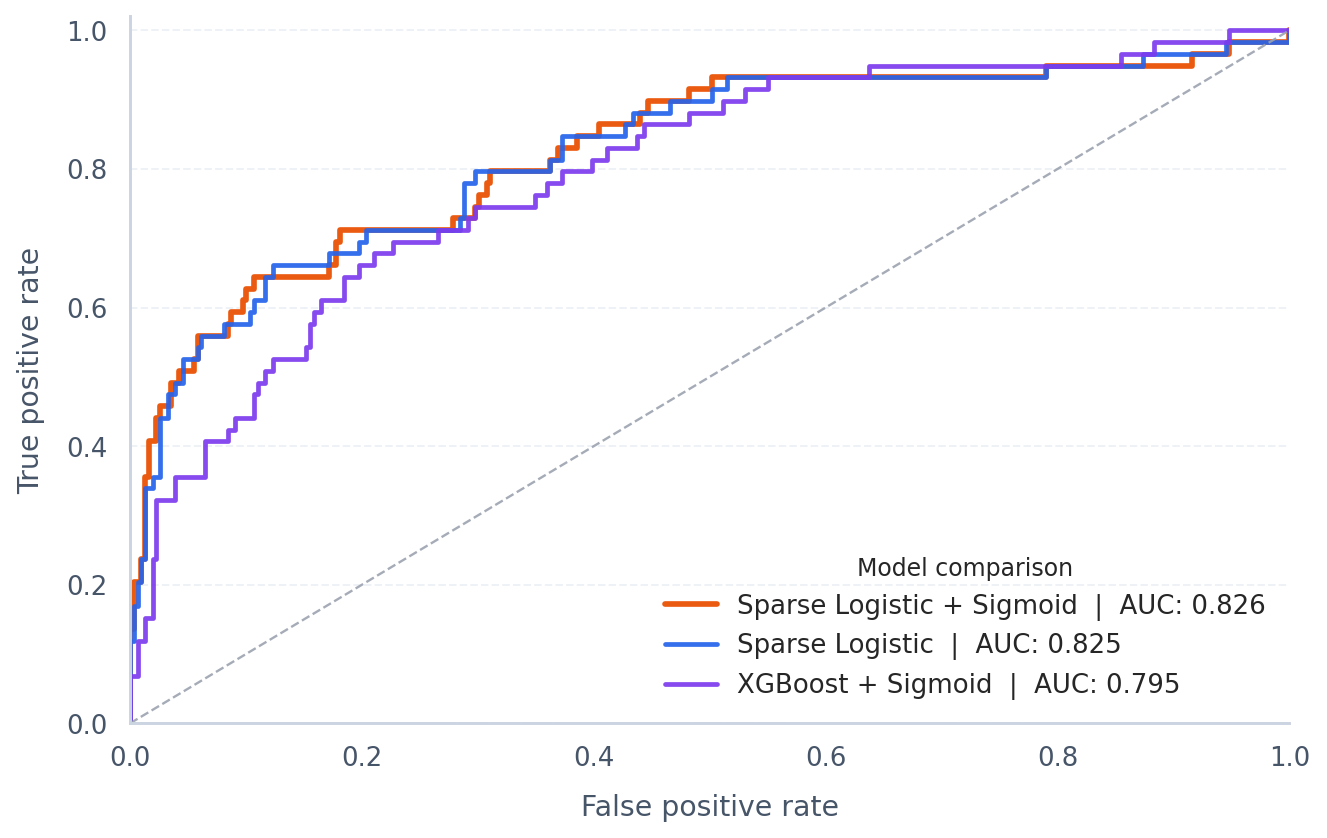

In [21]:
curve_palette = {
    name: [THEME["blue"], THEME["orange"], THEME["purple"]][i % 3]
    for i, name in enumerate(trained_models.keys())
}

roc_rank = sorted(
    trained_models.items(),
    key=lambda kv: roc_auc_score(y_test, kv[1]["proba"]),
    reverse=True
)

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)

for i, (model_name, meta) in enumerate(roc_rank):
    fpr, tpr, _ = roc_curve(y_test, meta["proba"])
    auc_score = roc_auc_score(y_test, meta["proba"])

    ax.plot(
        fpr,
        tpr,
        label=f"{model_name}  |  AUC: {auc_score:.3f}",
        color=curve_palette.get(model_name, THEME["slate"]),
        linewidth=2.4 if i == 0 else 2.0,
        alpha=0.98 if i == 0 else 0.92
    )

ax.plot(
    [0, 1], [0, 1],
    linestyle="--",
    linewidth=1.0,
    color="#9CA3AF",
    alpha=0.9
)

style_axis(ax, xlabel="False positive rate", ylabel="True positive rate")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

legend = ax.legend(
    frameon=False,
    loc="lower right",
    title="Model comparison"
)
plt.setp(legend.get_title(), fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig_card(fig, width=CHART_CARD_WIDTH)

#### **Model discrimination — precision/recall curves**

The precision/recall view is the primary discrimination panel for the imbalanced target, and the legend now shows average precision directly for a cleaner comparison across shortlisted models.


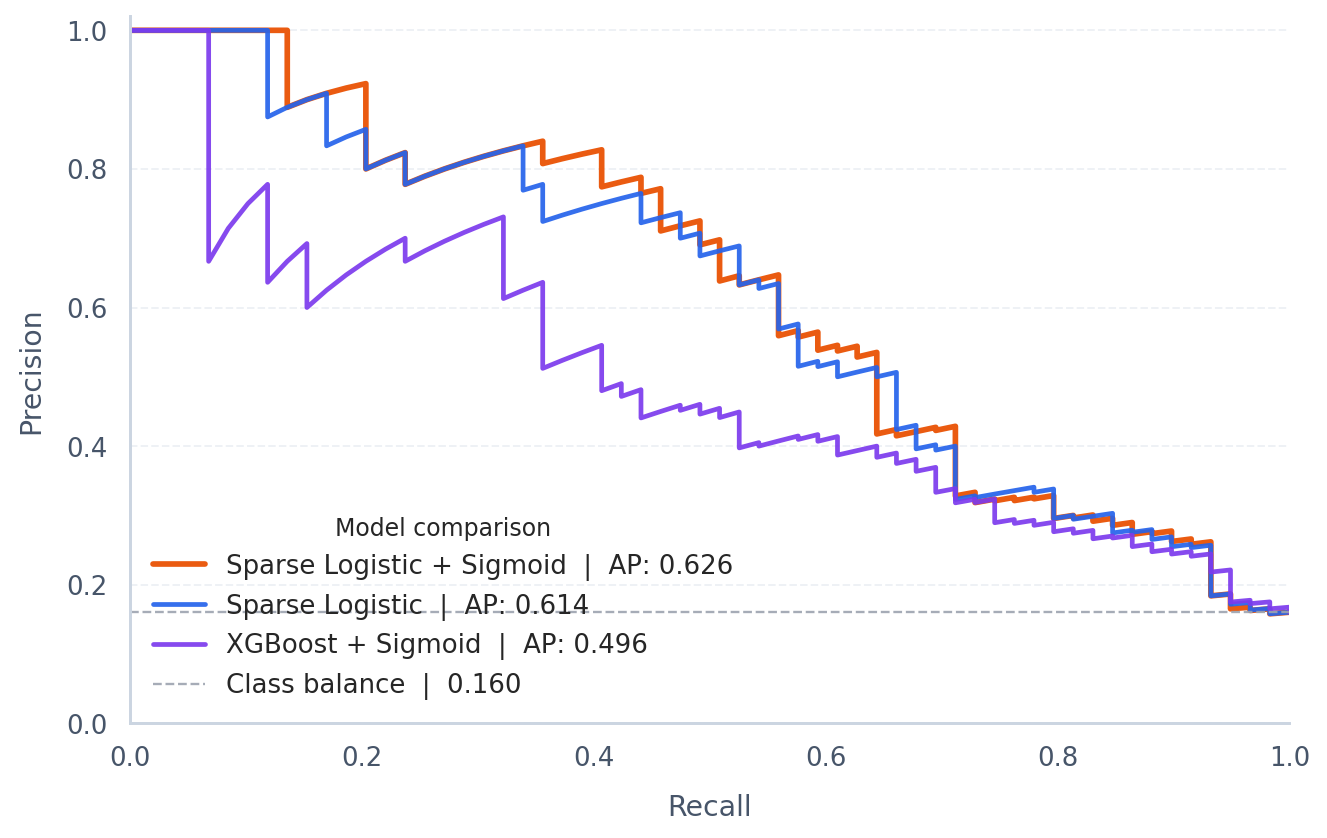

In [22]:
curve_palette = {
    name: [THEME["blue"], THEME["orange"], THEME["purple"]][i % 3]
    for i, name in enumerate(trained_models.keys())
}

pr_rank = sorted(
    trained_models.items(),
    key=lambda kv: average_precision_score(y_test, kv[1]["proba"]),
    reverse=True
)

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)

for i, (model_name, meta) in enumerate(pr_rank):
    precision, recall, _ = precision_recall_curve(y_test, meta["proba"])
    ap_score = average_precision_score(y_test, meta["proba"])

    ax.plot(
        recall,
        precision,
        label=f"{model_name}  |  AP: {ap_score:.3f}",
        color=curve_palette.get(model_name, THEME["slate"]),
        linewidth=2.4 if i == 0 else 2.0,
        alpha=0.98 if i == 0 else 0.92
    )

baseline = y_test.mean()
ax.hlines(
    baseline, 0, 1,
    linestyle="--",
    linewidth=1.0,
    color="#9CA3AF",
    alpha=0.9,
    label=f"Class balance  |  {baseline:.3f}"
)

style_axis(ax, xlabel="Recall", ylabel="Precision")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend = ax.legend(
    frameon=False,
    loc="lower left",
    title="Model comparison"
)
plt.setp(legend.get_title(), fontsize=10)

fig_card(fig, width=CHART_CARD_WIDTH)

#### **Score separation — predicted risk by actual outcome**

This view shows whether the selected model assigns meaningfully higher scores to actual exit cases than to stay cases.


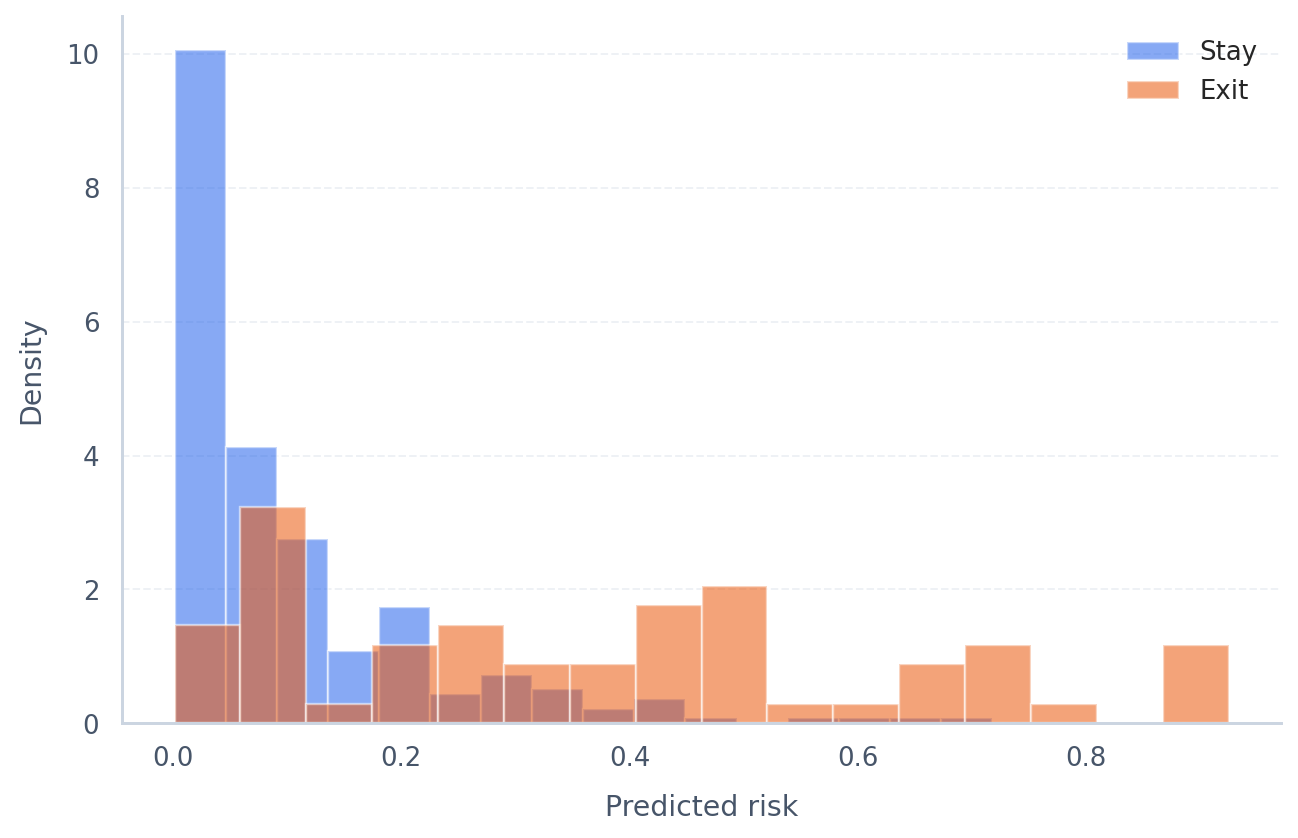

In [23]:
score_sep = pd.DataFrame({
    "ActualAttrition": y_test.map({0: "Stay", 1: "Exit"}).values,
    "PredictedRisk": champion_proba
})

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
for label, color in [("Stay", THEME["blue"]), ("Exit", THEME["orange"])]:
    vals = score_sep.loc[score_sep["ActualAttrition"] == label, "PredictedRisk"].values
    ax.hist(vals, bins=16, alpha=0.55, density=True, label=label, color=color, edgecolor="white")
style_axis(ax, xlabel="Predicted risk", ylabel="Density")
ax.legend(frameon=False, loc="upper right")
fig_card(fig, width=CHART_CARD_WIDTH)

## 8.2 Threshold, calibration, and operating view

A workforce risk model should be reviewed beyond one headline metric. The next panels show score separation, tuned operating behavior, calibration quality, and the degree to which realized attrition concentrates in the upper risk bands.

#### **Champion confusion matrix**

The confusion matrix summarizes how the selected threshold splits predictions between detected exits, missed exits, and false alerts.


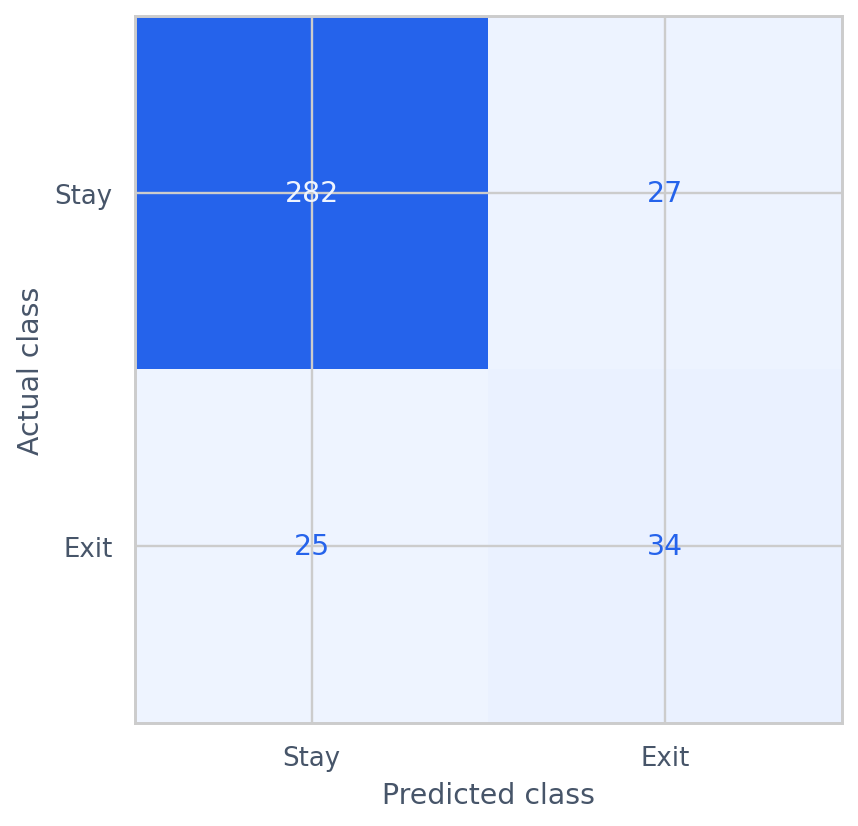

In [24]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
ConfusionMatrixDisplay.from_predictions(
    y_test,
    champion_pred_tuned,
    display_labels=["Stay", "Exit"],
    cmap=LinearSegmentedColormap.from_list(
        "cm",
        ["#EEF4FF", "#C7DBFF", "#7AA2F7", THEME["blue"]]
    ),
    colorbar=False,
    ax=ax
)
ax.set_xlabel("Predicted class", color=THEME["slate"])
ax.set_ylabel("Actual class", color=THEME["slate"])
ax.tick_params(colors=THEME["slate"])
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Probability calibration check**

Calibration shows how closely predicted probabilities align with realized outcomes and helps judge whether the score can be read as a usable risk layer.


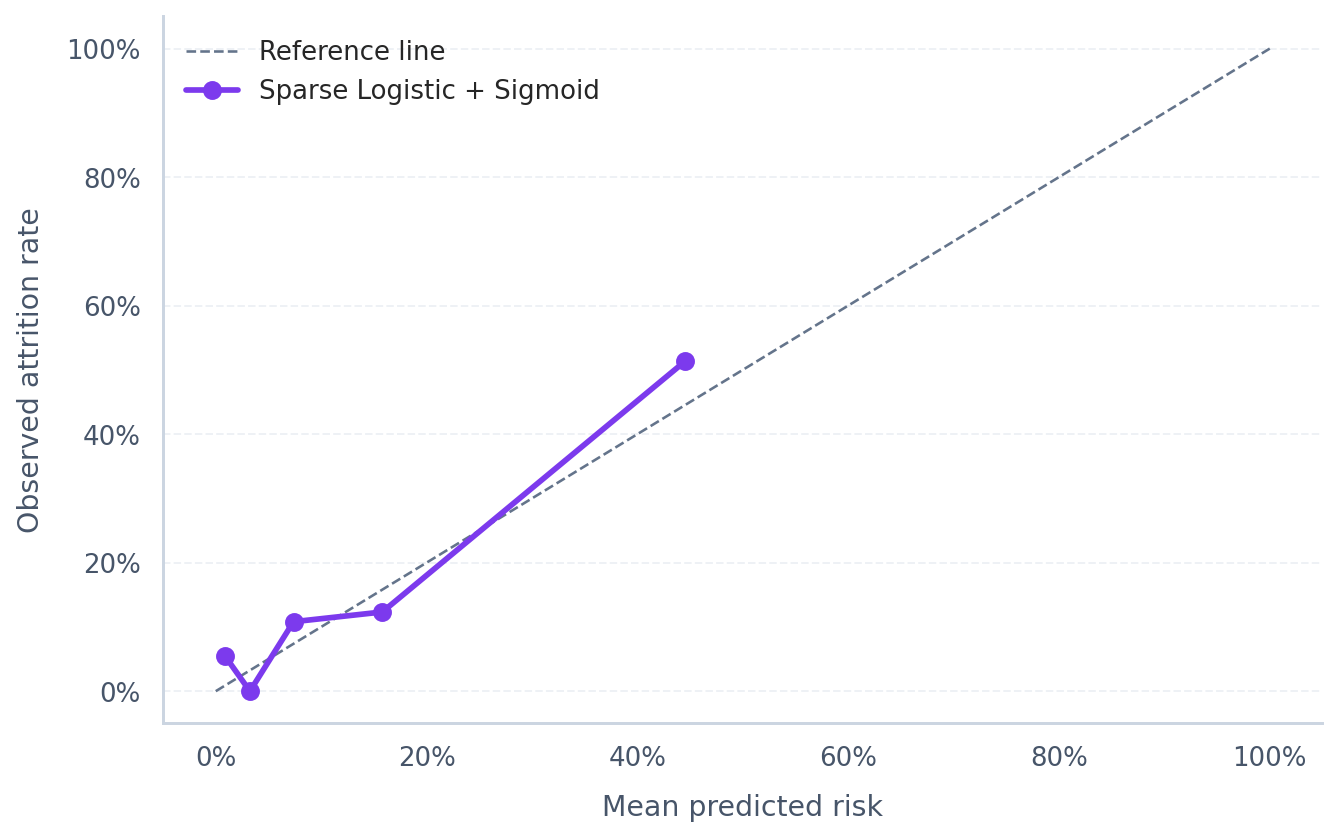

In [25]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
ax.plot([0, 1], [0, 1], linestyle="--", color=THEME["muted"], linewidth=1.1, label="Reference line")
ax.plot(
    calibration_df["MeanPredictedRisk"],
    calibration_df["ObservedAttritionRate"],
    marker="o",
    linewidth=2.4,
    markersize=7,
    color=THEME["purple"],
    label=champion_name
)
style_axis(ax, xlabel="Mean predicted risk", ylabel="Observed attrition rate", x_percent=True, y_percent=True)
ax.legend(frameon=False, loc="upper left")
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Risk concentration — test-set lift by decile**

Lift by decile shows whether the highest model scores truly capture a disproportionate share of realized attrition.


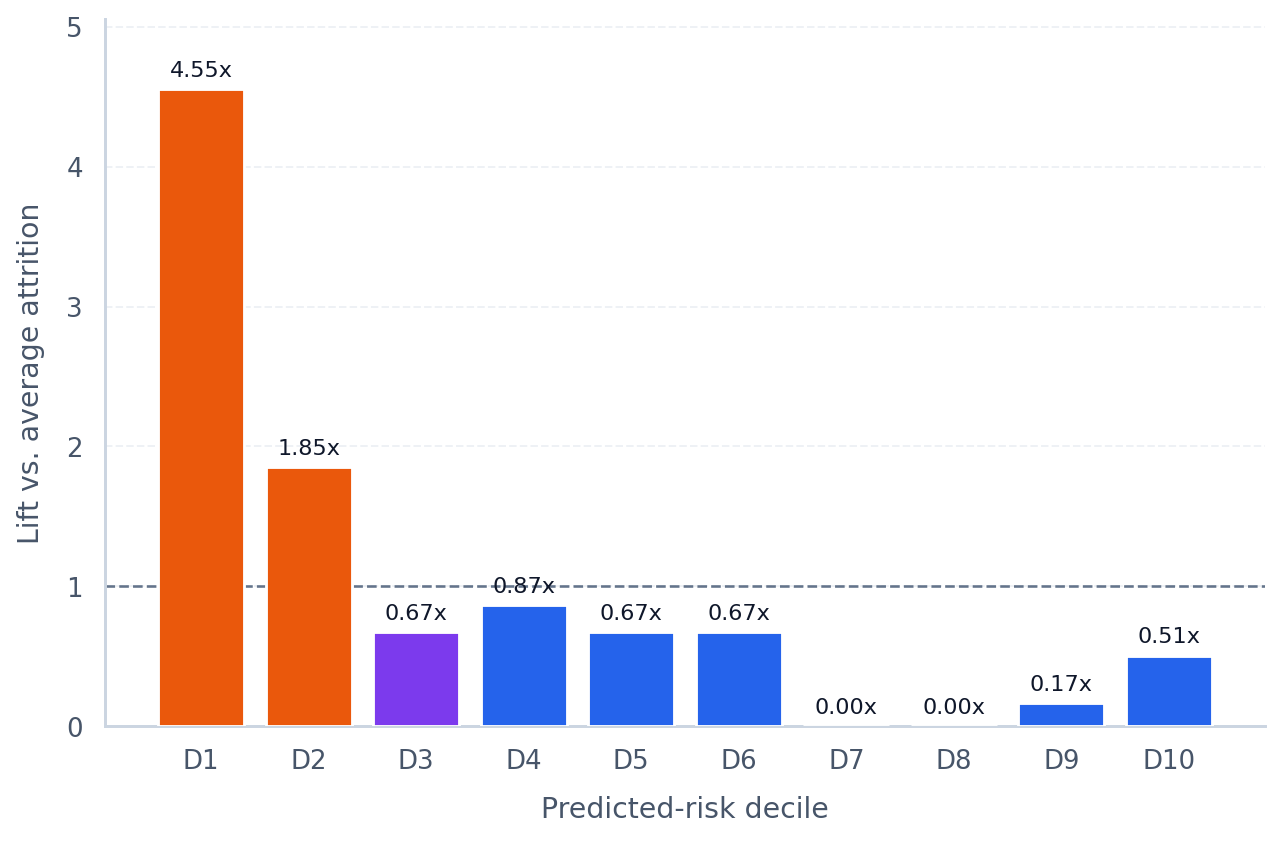

In [26]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
lift_plot = lift_table.sort_values("AvgPredictedRisk", ascending=False).copy()
bar_colors = [
    THEME["orange"] if i < 2 else THEME["purple"] if i == 2 else THEME["blue"]
    for i in range(len(lift_plot))
]
bars = ax.bar(
    lift_plot["RiskDecile"],
    lift_plot["LiftVsAverage"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1.2,
    zorder=3
)
style_axis(ax, xlabel="Predicted-risk decile", ylabel="Lift vs. average attrition")
ax.axhline(1.0, linestyle="--", linewidth=1.1, color=THEME["muted"], zorder=2)
ax.set_ylim(0, max(lift_plot["LiftVsAverage"].max() + 0.5, 1.6))
for bar, value in zip(bars, lift_plot["LiftVsAverage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.06,
        f"{value:.2f}x",
        ha="center",
        va="bottom",
        fontsize=9.5,
        color=THEME["text"]
    )
ax.tick_params(axis="x", rotation=0)
fig_card(fig, width=CHART_CARD_WIDTH)

<a id="9-explainability--what-drives-employee-exit"></a>

# 9. 🔎 Explainability — What Drives Employee Exit?

The explainability layer keeps business language in the foreground. It combines model-based ranking with simpler structural views so the risk story remains interpretable in workforce terms.

In [27]:
perm = permutation_importance(
    champion_model,
    X_test,
    y_test,
    n_repeats=8,
    random_state=42,
    scoring="roc_auc"
)

perm_df = (
    pd.DataFrame({
        "Feature": X_test.columns,
        "Importance": perm.importances_mean
    })
    .sort_values("Importance", ascending=False)
    .head(12)
)

signal_driver_note = pd.DataFrame({
    "ChampionModel": [champion_name],
    "InterpretationLayer": ["Permutation importance on the deployed champion, anchored by the sparse scorecard signal footprint"],
    "SparseSignalCount": [selected_signal_df["EncodedSignals"].sum() if "EncodedSignals" in selected_signal_df.columns else np.nan]
})

corr_cols = [
    c for c in [
        "MonthlyIncome",
        "TotalWorkingYears",
        "YearsAtCompany",
        "YearsSinceLastPromotion",
        "SatisfactionComposite",
        "WorkloadPressureScore",
        "CareerFrictionScore",
        "AttritionFlag"
    ] if c in df_fe.columns
]

In [28]:
df_tabs([
    ("Top Drivers", perm_df, 4, 15),
    ("Sparse Signals", selected_signal_df, 3, 15),
    ("Signal Detail", selected_signal_detail_df, 3, 18),
    ("Driver Note", signal_driver_note, 2, 5),
], panel_title="Explainability Board")

,Feature,Importance
13,OverTime,+0.076
29,SatisfactionComposite,+0.041
12,NumCompaniesWorked,+0.024
26,IncomeBand,+0.020
22,YearsSinceLastPromotion,+0.016
1,BusinessTravel,+0.016
10,MaritalStatus,+0.015
6,JobInvolvement,+0.014
24,AgeBand,+0.014
2,Department,+0.012


#### **Top model drivers by permutation importance**

This panel highlights which variables change model performance the most when their information is disrupted.


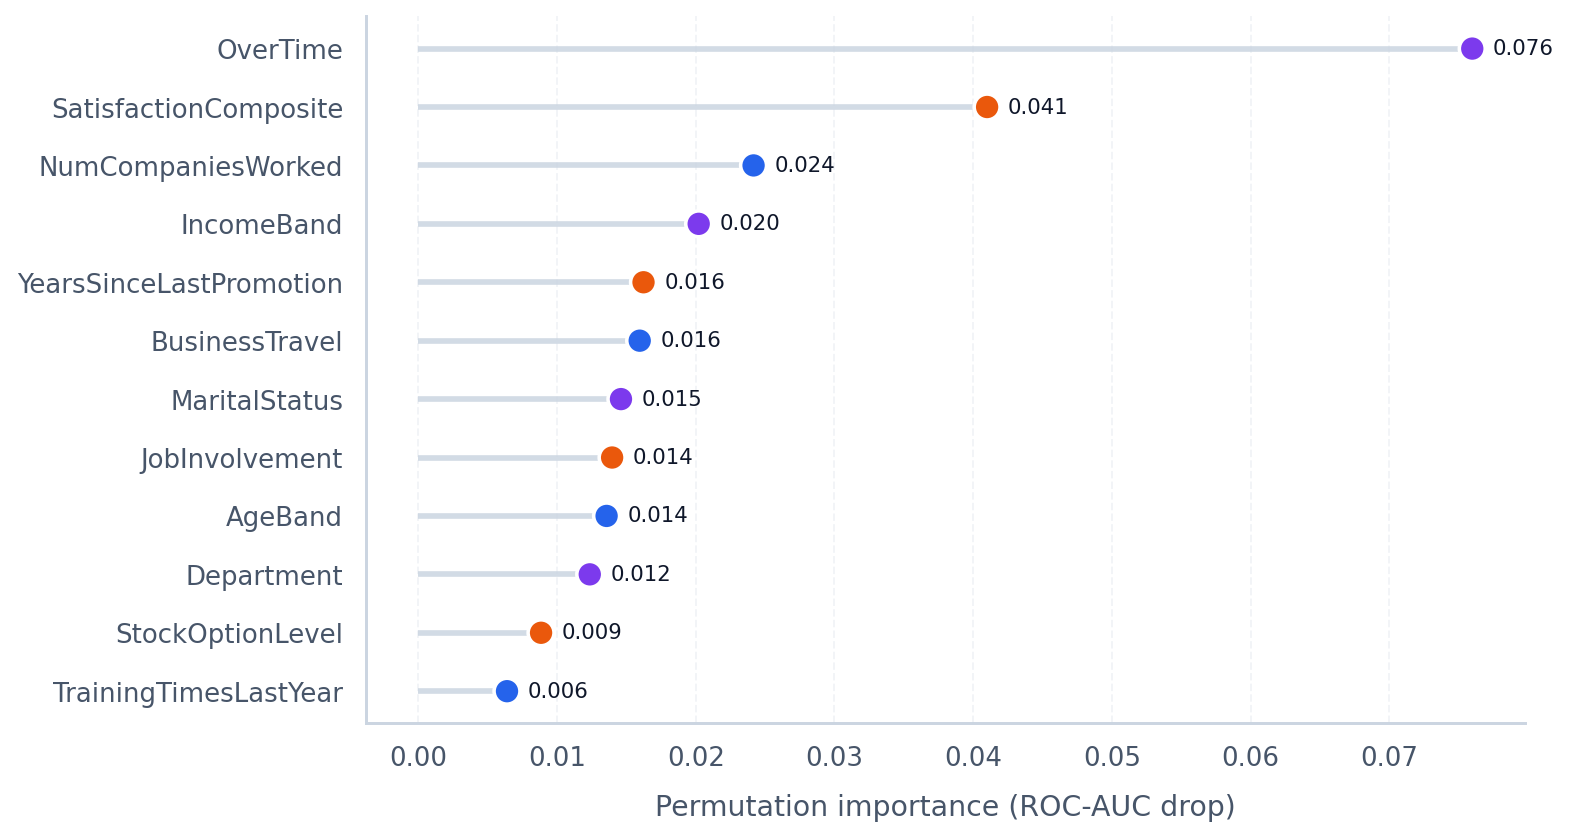

In [29]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
plot_df = perm_df.sort_values("Importance", ascending=True).reset_index(drop=True)
y_pos = np.arange(len(plot_df))

driver_colors = [
    [THEME["blue"], THEME["orange"], THEME["purple"]][i % 3]
    for i in range(len(plot_df))
]

ax.hlines(y=y_pos, xmin=0, xmax=plot_df["Importance"], color=THEME["grid"], linewidth=2.4, alpha=0.85)
ax.scatter(
    plot_df["Importance"],
    y_pos,
    s=120,
    c=driver_colors,
    edgecolor="white",
    linewidth=1.5,
    zorder=3
)

ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df["Feature"])
style_axis(ax, xlabel="Permutation importance (ROC-AUC drop)", ylabel="", xgrid=True)

for xpos, ypos in zip(plot_df["Importance"], y_pos):
    ax.text(xpos + 0.0015, ypos, f"{xpos:.3f}", va="center", ha="left", fontsize=9, color=THEME["text"])

fig_card(fig, width=CHART_CARD_WIDTH)

#### **Correlation view of core engineered drivers**

The correlation map helps distinguish whether the main engineered signals reinforce one another or are largely capturing separate parts of the workforce story.


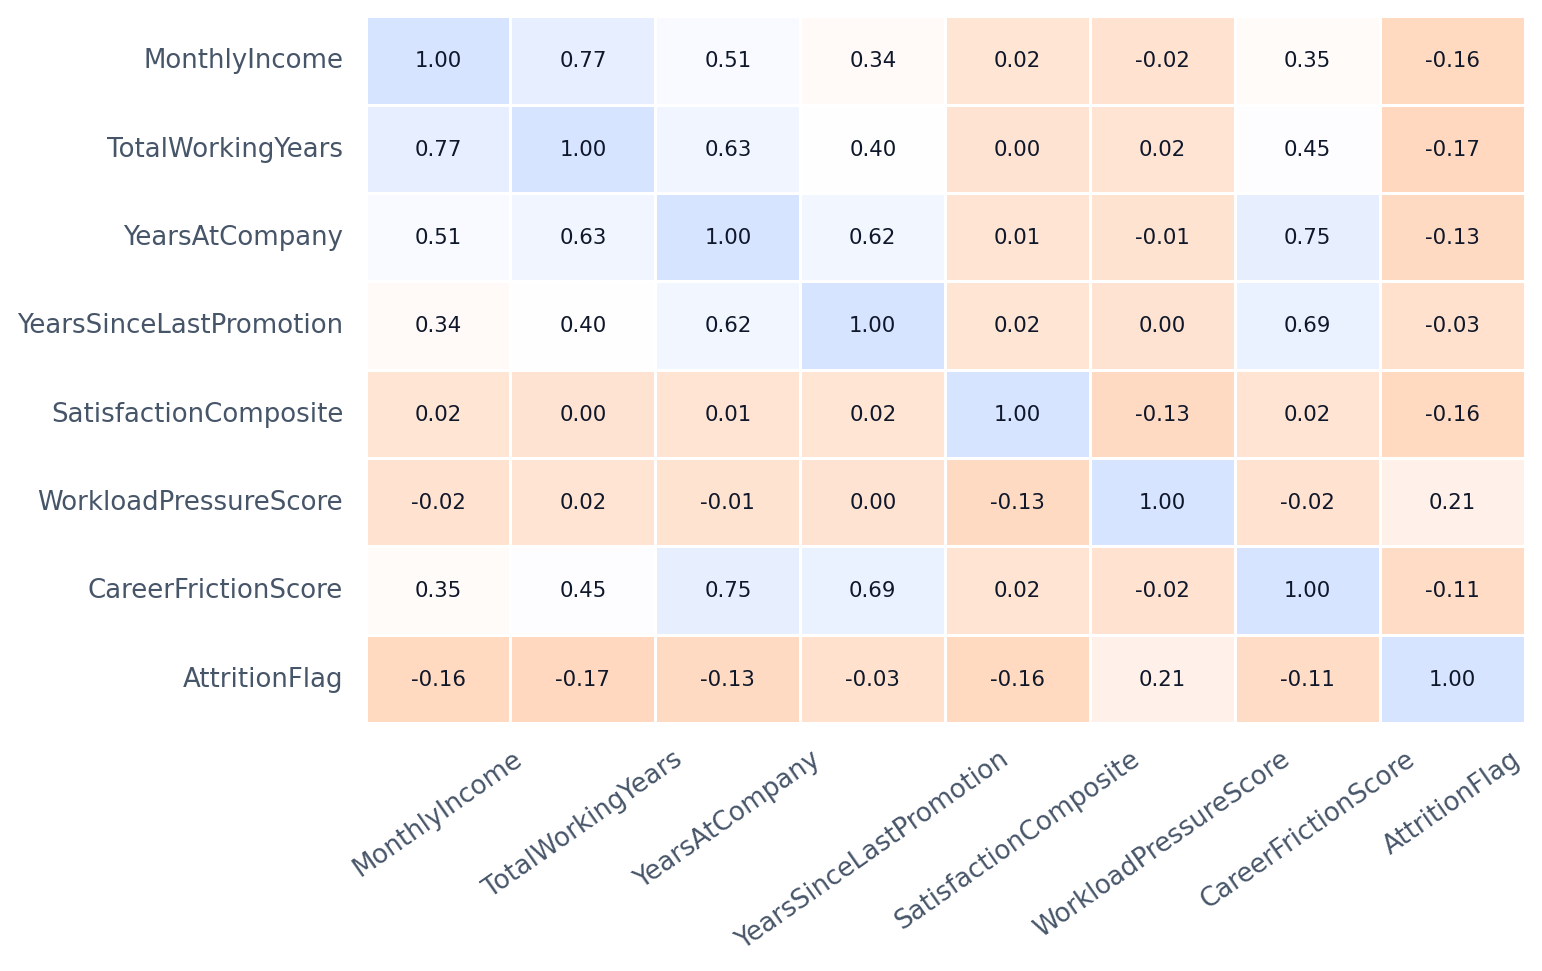

In [30]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
sns.heatmap(
    df_fe[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cbar=False,
    cmap=LinearSegmentedColormap.from_list(
        "corr_map",
        [THEME["orange_soft"], "#FFFFFF", THEME["blue_soft"]]
    ),
    linewidths=1.1,
    linecolor="white",
    annot_kws={"fontsize": 9, "color": THEME["text"]},
    ax=ax
)
ax.tick_params(axis="x", rotation=35, colors=THEME["slate"])
ax.tick_params(axis="y", rotation=0, colors=THEME["slate"])
fig_card(fig, width=CHART_CARD_WIDTH)

<a id="10-monitoring-layer--visible-risk-views"></a>

# 10. 👀 Monitoring Layer — Visible Risk Views

The monitoring layer turns the selected score into readable control views for recurring review. The emphasis is on segment visibility, subgroup watchpoints, and action prioritization.

In [31]:
dashboard_X = df_fe[model_signal_cols].copy()

df_fe["Attrition_Prob"] = champion_model.predict_proba(dashboard_X)[:, 1]
df_fe["Predicted_Attrition_Class_Default"] = (df_fe["Attrition_Prob"] >= 0.50).astype(int)
df_fe["Predicted_Attrition_Class_Tuned"] = (df_fe["Attrition_Prob"] >= best_threshold).astype(int)
df_fe["ModelChampion"] = champion_name
df_fe["ChampionThreshold"] = best_threshold

df_fe["RiskDecile"] = pd.qcut(
    df_fe["Attrition_Prob"].rank(method="first"),
    q=10,
    labels=[f"D{i}" for i in range(10, 0, -1)]
)

df_fe["RiskBand"] = pd.cut(
    df_fe["Attrition_Prob"],
    bins=[-0.01, 0.20, 0.40, 0.60, 1.00],
    labels=["Low", "Guardrail", "Elevated", "Critical"]
)

df_fe["InterventionPriority"] = np.select(
    [
        (df_fe["Attrition_Prob"] >= 0.60),
        (df_fe["Attrition_Prob"] >= 0.40),
        (df_fe["Attrition_Prob"] >= 0.20)
    ],
    ["P1", "P2", "P3"],
    default="P4"
)

df_fe["ActionBucket"] = np.select(
    [
        df_fe["RiskSegment"].eq("Workload Pressure"),
        df_fe["RiskSegment"].eq("Early Career Pay Pressure"),
        df_fe["RiskSegment"].eq("Career Friction")
    ],
    [
        "Workload review",
        "Early-career retention",
        "Mobility and promotion review"
    ],
    default="Baseline monitor"
)

segment_monitor = (
    df_fe.groupby("RiskSegment", as_index=False)
         .agg(
             Headcount=("AttritionFlag", "size"),
             ActualAttritionRate=("AttritionFlag", "mean"),
             AvgPredictedRisk=("Attrition_Prob", "mean"),
             OvertimeShare=("OvertimeFlag", "mean"),
             AvgMonthlyIncome=("MonthlyIncome", "mean")
         )
         .sort_values("AvgPredictedRisk", ascending=False)
)

fairness_monitor = (
    df_fe.groupby(["Gender", "AgeBand"], as_index=False, observed=False)
         .agg(
             Headcount=("AttritionFlag", "size"),
             ActualAttritionRate=("AttritionFlag", "mean"),
             AvgPredictedRisk=("Attrition_Prob", "mean")
         )
         .sort_values(["Gender", "AvgPredictedRisk"], ascending=[True, False])
)

tenure_monitor = (
    df_fe.groupby("TenureBand", as_index=False, observed=False)
         .agg(
             Headcount=("AttritionFlag", "size"),
             ActualAttritionRate=("AttritionFlag", "mean"),
             AvgPredictedRisk=("Attrition_Prob", "mean"),
             AvgYearsSincePromotion=("YearsSinceLastPromotion", "mean")
         )
         .sort_values("AvgPredictedRisk", ascending=False)
)

intervention_queue = (
    df_fe.groupby("RiskSegment", as_index=False)
         .agg(
             Employees=("AttritionFlag", "size"),
             HighRiskEmployees=("Predicted_Attrition_Class_Tuned", "sum"),
             AvgPredictedRisk=("Attrition_Prob", "mean"),
             AvgSatisfaction=("SatisfactionComposite", "mean")
         )
)

intervention_queue["SuggestedFocus"] = np.select(
    [
        intervention_queue["RiskSegment"].eq("Workload Pressure"),
        intervention_queue["RiskSegment"].eq("Early Career Pay Pressure"),
        intervention_queue["RiskSegment"].eq("Career Friction")
    ],
    [
        "Review workload, overtime, and manager support",
        "Check reward fit and onboarding support",
        "Review mobility, promotion pacing, and role fit"
    ],
    default="Keep as baseline monitoring group"
)

watchlist = (
    df_fe[[
        "EmployeeNumber", "Department", "JobRole", "RiskSegment", "ActionBucket",
        "Attrition_Prob", "RiskBand", "InterventionPriority",
        "OvertimeFlag", "CareerFrictionScore", "WorkloadPressureScore",
        "SatisfactionComposite", "Attrition"
    ]]
    .sort_values(["InterventionPriority", "Attrition_Prob"], ascending=[True, False])
    .head(15)
    .reset_index(drop=True)
)

df_tabs([
    ("Segment Monitor", segment_monitor, 3, 20),
    ("Fairness Monitor", fairness_monitor, 3, 20),
    ("Tenure Monitor", tenure_monitor, 3, 20),
    ("Intervention Queue", intervention_queue, 3, 20),
    ("Watchlist", watchlist, 3, 15),
], panel_title="Monitoring Board")

#### **Observed vs predicted risk by segment**

This comparison shows whether the model is directionally aligned with observed segment-level risk patterns.


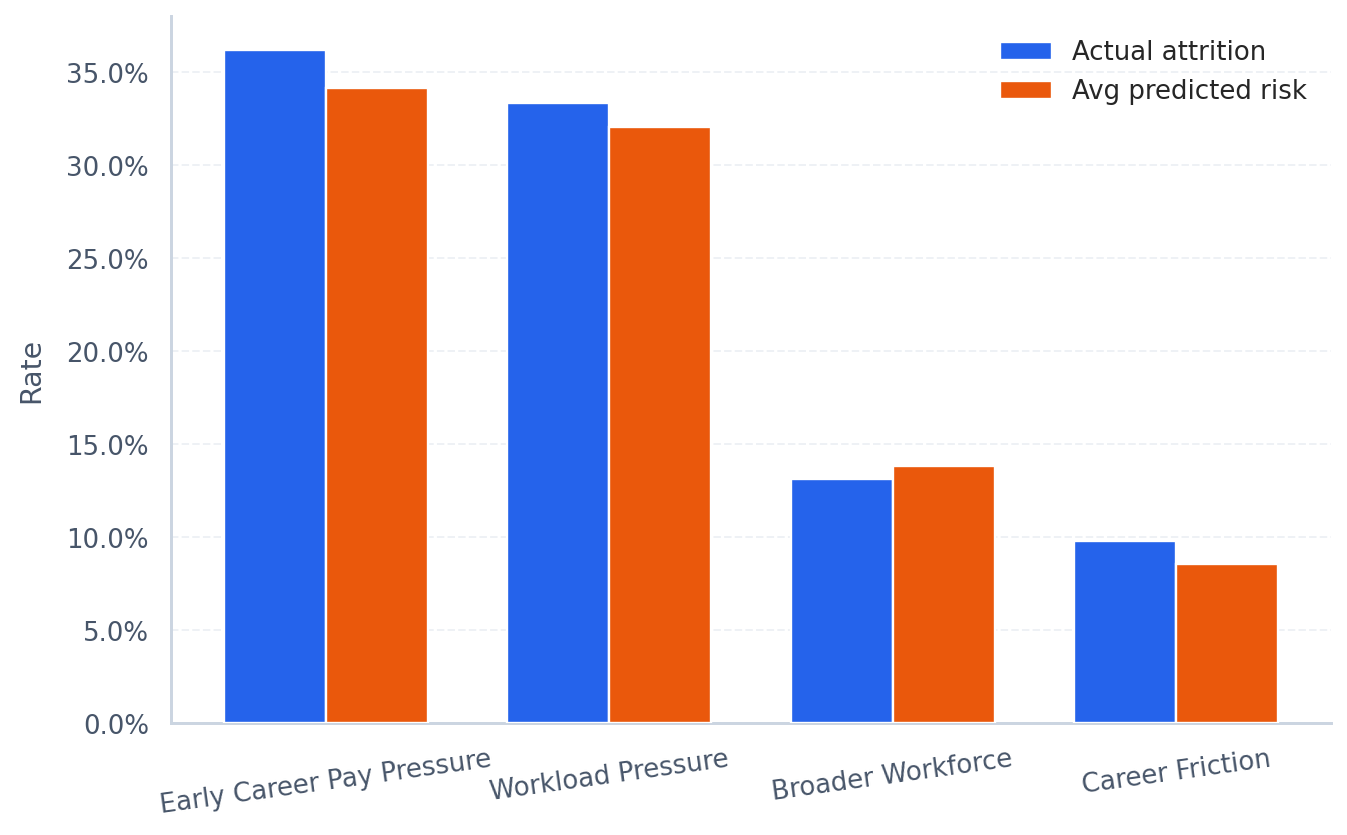

In [32]:
seg_plot = segment_monitor.copy().sort_values("AvgPredictedRisk", ascending=False)

fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
x = np.arange(seg_plot.shape[0])
bar_width = 0.36

ax.bar(
    x - bar_width / 2,
    seg_plot["ActualAttritionRate"],
    width=bar_width,
    color=THEME["blue"],
    label="Actual attrition",
    zorder=3
)
ax.bar(
    x + bar_width / 2,
    seg_plot["AvgPredictedRisk"],
    width=bar_width,
    color=THEME["orange"],
    label="Avg predicted risk",
    zorder=3
)

ax.set_xticks(x)
ax.set_xticklabels(seg_plot["RiskSegment"], rotation=8, ha="center")
ax.legend(frameon=False, loc="upper right")
style_axis(ax, xlabel="", ylabel="Rate", y_percent=True)
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Fairness watch — average predicted risk by gender and age band**

This panel checks whether predicted risk differs materially across major demographic groupings and therefore deserves closer review.


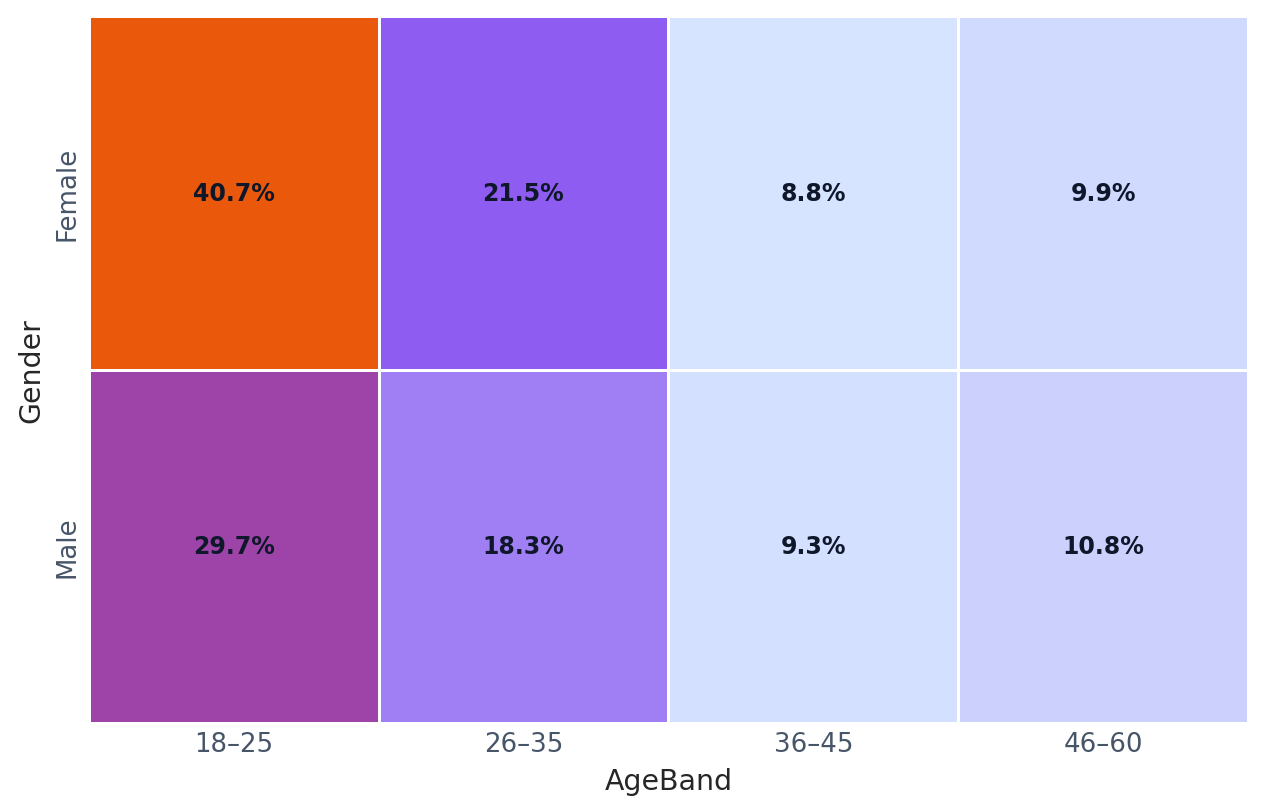

In [33]:
fairness_pivot = fairness_monitor.pivot(index="Gender", columns="AgeBand", values="AvgPredictedRisk")
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
sns.heatmap(
    fairness_pivot,
    annot=True,
    fmt=".1%",
    cbar=False,
    cmap=LinearSegmentedColormap.from_list(
        "fair_map",
        [THEME["blue_soft"], THEME["purple"], THEME["orange"]]
    ),
    linewidths=1.2,
    linecolor="white",
    annot_kws={"fontsize": 10, "fontweight": "bold", "color": THEME["text"]},
    ax=ax
)
ax.tick_params(colors=THEME["slate"], length=0)
fig_card(fig, width=CHART_CARD_WIDTH)

#### **Tenure watch — actual vs predicted risk**

The tenure view compares observed and predicted risk across employee lifecycle stages to see where the model tracks well and where caution is needed.


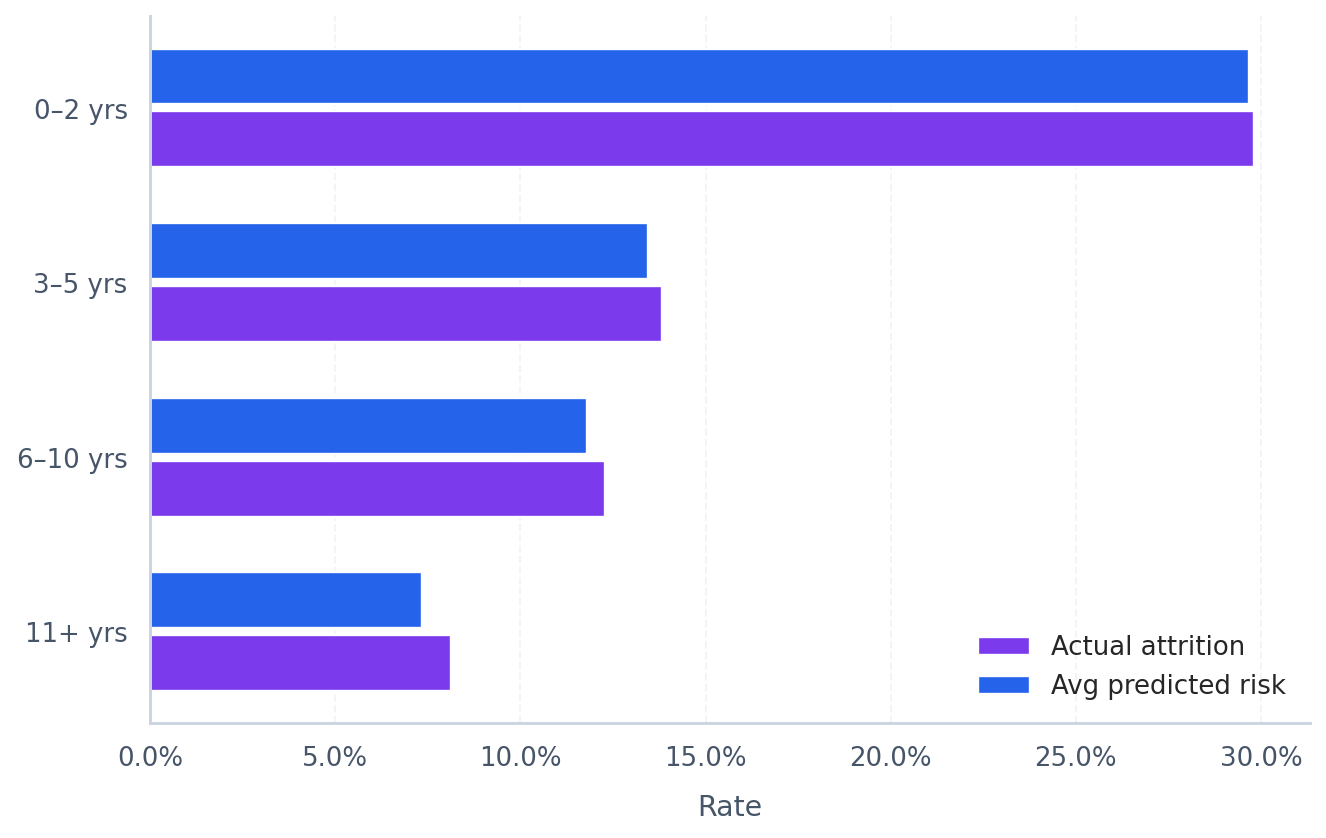

In [34]:
fig, ax = plt.subplots(figsize=CHART_FIGSIZE)
ten_plot = tenure_monitor.sort_values("AvgPredictedRisk", ascending=True).copy()
y_pos = np.arange(len(ten_plot))
ax.barh(
    y_pos - 0.18,
    ten_plot["ActualAttritionRate"],
    height=0.32,
    color=THEME["purple"],
    edgecolor="white",
    linewidth=1.0,
    label="Actual attrition"
)
ax.barh(
    y_pos + 0.18,
    ten_plot["AvgPredictedRisk"],
    height=0.32,
    color=THEME["blue"],
    edgecolor="white",
    linewidth=1.0,
    label="Avg predicted risk"
)
ax.set_yticks(y_pos)
ax.set_yticklabels(ten_plot["TenureBand"])
style_axis(ax, xlabel="Rate", ylabel="", x_percent=True, xgrid=True)
ax.legend(frameon=False, loc="lower right")
fig_card(fig, width=CHART_CARD_WIDTH)

<a id="11-executive-conclusions--data-export"></a>

# 11. 🚀 Executive Conclusions & Analytic Export

### Executive reading

A few conclusions remain consistent throughout the notebook:

- Attrition pressure is concentrated rather than diffuse, especially when workload, tenure, and progression signals are read together.
- Exploratory analysis and modeling point to the same general risk pattern: overtime, progression friction, reward positioning, and early-tenure exposure repeatedly surface near the top.
- The modeling layer improves prioritization without giving up interpretability.
- The dataset is well suited for decision-support analysis, while remaining limited for causal inference or intervention measurement.

### Analytic export

The final block writes a clean employee-level output and a compact summary bundle so the analysis can move forward with minimal reshaping.

In [35]:
export_cols = [
    "EmployeeNumber", "Attrition", "AttritionFlag",
    "Department", "JobRole", "JobLevel", "Gender", "MaritalStatus",
    "Age", "AgeBand", "MonthlyIncome", "IncomeBand", "DistanceFromHome",
    "BusinessTravel", "OverTime", "WorkLifeBalance", "JobSatisfaction",
    "EnvironmentSatisfaction", "RelationshipSatisfaction",
    "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager",
    "TenureBand", "PromotionLagBand",
    "OvertimeFlag", "LongCommuteFlag", "EarlyCareerFlag", "LowWorkLifeFlag",
    "SatisfactionComposite", "CareerFrictionScore", "WorkloadPressureScore",
    "IncomePerLevel", "YearsPerCompanyRatio", "PromotionStallIntensity",
    "RiskSegment", "ActionBucket",
    "Attrition_Prob", "Predicted_Attrition_Class_Default", "Predicted_Attrition_Class_Tuned",
    "RiskDecile", "RiskBand", "InterventionPriority", "ModelChampion", "ChampionThreshold"
]

export_dir = "/mnt/data"
os.makedirs(export_dir, exist_ok=True)
export_path = os.path.join(export_dir, "hr_attrition_dashboard_export_recalibrated.csv")
df_fe[export_cols].to_csv(export_path, index=False)

display(HTML(f"""
<div style="display:flex;justify-content:center;margin-top:8px;">
  <div style="width:80%;background:#EEF4FF;border:1px solid #D6E4FF;border-radius:16px;padding:16px 18px;">
      <div style="font-size:18px;font-weight:800;color:{THEME['blue']};">Enriched dataset exported</div>
      <div style="color:#475569;margin-top:4px;">Saved to: <b>{export_path}</b></div>
      <div style="color:#475569;margin-top:4px;">Rows: <b>{df_fe.shape[0]:,}</b> • Columns: <b>{len(export_cols)}</b></div>
  </div>
</div>
"""))

df_tabs([("Export Preview", df_fe[export_cols].head(10), 2, 10)], panel_title="Export Preview")

,EmployeeNumber,Attrition,AttritionFlag,Department,JobRole,JobLevel,Gender,MaritalStatus,Age,AgeBand,MonthlyIncome,IncomeBand,DistanceFromHome,BusinessTravel,OverTime,WorkLifeBalance,JobSatisfaction,EnvironmentSatisfaction,RelationshipSatisfaction,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TenureBand,PromotionLagBand,OvertimeFlag,LongCommuteFlag,EarlyCareerFlag,LowWorkLifeFlag,SatisfactionComposite,CareerFrictionScore,WorkloadPressureScore,IncomePerLevel,YearsPerCompanyRatio,PromotionStallIntensity,RiskSegment,ActionBucket,Attrition_Prob,Predicted_Attrition_Class_Default,Predicted_Attrition_Class_Tuned,RiskDecile,RiskBand,InterventionPriority,ModelChampion,ChampionThreshold
0,1,Yes,1,Sales,Sales Executive,2,Female,Single,41,36–45,"5,993",Q3,1,Travel_Rarely,Yes,1,4,2,1,8,6,4,0,5,6–10 yrs,0 yrs,1,0,0,1,2.00,1,2,"2,996",0.67,0.00,Workload Pressure,Workload review,66.7%,1,1,D1,Critical,P1,Sparse Logistic + Sigmoid,0.28
1,2,No,0,Research & Development,Research Scientist,2,Male,Married,49,46–60,"5,130",Q3,8,Travel_Frequently,No,3,2,3,4,10,10,7,1,7,6–10 yrs,1–2 yrs,0,0,0,0,3.00,2,0,"2,565",0.91,0.09,Career Friction,Mobility and promotion review,1.0%,0,0,D9,Low,P4,Sparse Logistic + Sigmoid,0.28
2,4,Yes,1,Research & Development,Laboratory Technician,1,Male,Single,37,36–45,"2,090",Q1 Low,2,Travel_Rarely,Yes,3,3,4,2,7,0,0,0,0,0–2 yrs,0 yrs,1,0,0,0,3.00,0,1,"2,090",0.00,0.00,Broader Workforce,Baseline monitor,67.2%,1,1,D1,Critical,P1,Sparse Logistic + Sigmoid,0.28
3,5,No,0,Research & Development,Research Scientist,1,Female,Married,33,26–35,"2,909",Q1 Low,3,Travel_Frequently,Yes,3,3,4,3,8,8,7,3,0,6–10 yrs,3–5 yrs,1,0,0,0,3.25,2,1,"2,909",0.89,0.33,Career Friction,Mobility and promotion review,22.8%,0,0,D3,Guardrail,P3,Sparse Logistic + Sigmoid,0.28
4,7,No,0,Research & Development,Laboratory Technician,1,Male,Married,27,26–35,"3,468",Q2,2,Travel_Rarely,No,3,2,1,4,6,2,2,2,2,0–2 yrs,1–2 yrs,0,0,0,0,2.50,0,0,"3,468",0.29,0.67,Broader Workforce,Baseline monitor,25.0%,0,0,D3,Guardrail,P3,Sparse Logistic + Sigmoid,0.28
5,8,No,0,Research & Development,Laboratory Technician,1,Male,Single,32,26–35,"3,068",Q2,2,Travel_Frequently,No,2,4,4,3,8,7,7,3,6,6–10 yrs,3–5 yrs,0,0,0,1,3.25,3,1,"3,068",0.78,0.38,Career Friction,Mobility and promotion review,9.4%,0,0,D5,Low,P4,Sparse Logistic + Sigmoid,0.28
6,10,No,0,Research & Development,Laboratory Technician,1,Female,Married,59,46–60,"2,670",Q1 Low,3,Travel_Rarely,Yes,2,1,3,1,12,1,0,0,0,0–2 yrs,0 yrs,1,0,0,1,1.75,0,2,"2,670",0.08,0.00,Workload Pressure,Workload review,32.4%,0,1,D2,Guardrail,P3,Sparse Logistic + Sigmoid,0.28
7,11,No,0,Research & Development,Laboratory Technician,1,Male,Divorced,30,26–35,"2,693",Q1 Low,24,Travel_Rarely,No,3,3,4,2,1,1,0,0,0,0–2 yrs,0 yrs,0,1,1,0,3.00,0,1,"2,693",0.50,0.00,Early Career Pay Pressure,Early-career retention,25.3%,0,0,D3,Guardrail,P3,Sparse Logistic + Sigmoid,0.28
8,12,No,0,Research & Development,Manufacturing Director,3,Male,Single,38,36–45,"9,526",Q4 High,23,Travel_Frequently,No,3,3,4,2,10,9,7,1,8,6–10 yrs,1–2 yrs,0,1,0,0,3.00,2,1,"3,175",0.82,0.10,Career Friction,Mobility and promotion review,3.5%,0,0,D7,Low,P4,Sparse Logistic + Sigmoid,0.28
9,13,No,0,Research & Development,Healthcare Representative,2,Male,Married,36,36–45,"5,237",Q3,27,Travel_Rarely,No,2,3,3,2,17,7,7,7,7,6–10 yrs,6+ yrs,0,1,0,1,2.50,3,2,"2,618",0.39,0.88,Career Friction,Mobility and promotion review,4.0%,0,0,D7,Low,P4,Sparse Logistic + Sigmoid,0.28


<div style="
  background: linear-gradient(to right, #eff6ff, #f5f3ff);
  padding: 20px;
  border-radius: 12px;
  color: #1e293b;
  font-size: 16px;
  line-height: 1.7;
  box-shadow: 0 3px 10px rgba(15,23,42,0.12);
  margin-top: 30px;
  border: 1px solid #c4b5fd;
">

  <h1 style="color: #4F46E5; margin-top: 0;">💬 Support & Feedback</h1>

  <p>
    If this <strong>HR attrition and retention</strong> notebook helped you explore workforce patterns,
    sharpen your decision-support thinking, or inspired your own analysis, you can support the work by:
  </p>

  <ul>
    <li>⭐️ <strong>Upvoting</strong> the notebook so it can reach more people interested in HR analytics</li>
    <li>💬 <strong>Leaving a comment</strong> to share suggestions, questions, or ideas for further analysis</li>
    <li>🔁 <strong>Forking</strong> it to extend the visuals, improve the modeling layer, or adapt it to your own workforce use case</li>
  </ul>

  <p>
    Feedback and engagement help make this kind of open, interpretable, and decision-oriented analytics
    more useful for the wider data community.
  </p>

  <blockquote style="
    background-color: #eef2ff;
    border-left: 5px solid #4F46E5;
    padding: 12px 18px;
    margin-top: 20px;
    font-style: italic;
    color: #312e81;">
    <em>Better workforce insight starts with better questions, clearer signals, and more thoughtful decisions. 📊</em>
  </blockquote>

</div>